# Laneless Karalakou RL Experiments

Train and compare four policy families in the custom lane-free highway-env extension using the Karalakou-style reward setup:

- PPO baseline
- DDPG without CBF
- DDPG with CBF in the reward through the shielded environment
- DDPG with CBF in both the reward and actor loss through guided CBF imitation

The simulator still comes from `laneless highway env/lane_free_env.py`. This notebook keeps simulator code separate from RL wrappers, training, evaluation, and rendering.

## Shared Setup

### Dependencies

If an import fails, install the dependencies in the selected notebook interpreter:

```python
# !python -m pip install -U stable-baselines3[extra] gymnasium highway-env torch numpy pandas matplotlib pygame qpsolvers osqp clarabel
```

In [ ]:
from __future__ import annotations

import faulthandler
import os
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Optional

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("TORCH_NUM_THREADS", "1")
os.environ.setdefault("PYTHONFAULTHANDLER", "1")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy
import sympy.core  # Eager import for PyTorch/SB3 symbolic-shape compatibility.
import torch
from IPython.display import display
from stable_baselines3 import DDPG, PPO
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise, VectorizedActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "laneless highway env" / "lane_free_env.py").exists():
            return candidate
        nested = candidate / "highway-rl-decision-making"
        if (nested / "laneless highway env" / "lane_free_env.py").exists():
            return nested
    raise RuntimeError("Could not find the project root containing 'laneless highway env/lane_free_env.py'.")


PROJECT_ROOT = find_project_root()
LANE_FREE_DIR = PROJECT_ROOT / "laneless highway env"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "lanelessKaralakou"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

lane_free_dir_str = str(LANE_FREE_DIR)
if lane_free_dir_str not in sys.path:
    sys.path.insert(0, lane_free_dir_str)

import lane_free_env  # noqa: F401: registers lane-free-v0

warnings.filterwarnings("ignore", message=r"OSQP exited.*")
try:
    faulthandler.enable(all_threads=True)
except RuntimeError:
    pass
RUNNING_IN_NOTEBOOK = "ipykernel" in sys.modules

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    torch.backends.cudnn.benchmark = True

torch.set_num_threads(max(1, int(os.environ.get("TORCH_NUM_THREADS", "1"))))
try:
    torch.set_num_interop_threads(max(1, int(os.environ.get("TORCH_NUM_THREADS", "1"))))
except RuntimeError:
    pass

print("Project root:", PROJECT_ROOT)
print("Lane-free env dir:", LANE_FREE_DIR)
print("Device:", DEVICE)


### Karalakou Best Reward Wrapper

The paper's best-performing reward function combines:

- desired longitudinal speed cost `cx`
- lateral target/zone cost `cy`
- potential-field collision-risk cost `cf`
- collision penalty `rc`
- lateral acceleration cost `cay`
- overtake bonus `ro`

The wrapper below replaces the environment reward during training without changing the simulator source code.

In [14]:
class KaralakouRewardWrapper(gym.Wrapper):
    """Reward wrapper for Fields + Zones + Overtake + Collision Avoidance."""

    def __init__(self, env: gym.Env, reward_config: Optional[dict[str, float]] = None) -> None:
        super().__init__(env)
        self.reward_config = {
            "epsilon_r": 0.4,
            "wx": 1.0,
            "wy": 0.65,
            "wf": 1.0,
            "collision_penalty": -2.5,
            "way": 0.0,
            "overtake_bonus": 0.5,
            "timegap": 0.7,
            "ego_desired_speed": 20.0,
            "field_magnitude": 0.5,
            "field_px": 2.0,
            "field_py": 2.0,
            "field_pt": 1.0,
            "zone_margin": 0.15,
            "progress_reward_weight": 0.0,
            "progress_clip": 1.25,
        }
        if reward_config:
            self.reward_config.update(reward_config)

    @property
    def base_env(self):
        return self.env.unwrapped

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.base_env.vehicle.desired_speed = float(self.reward_config["ego_desired_speed"])
        return self._augment_observation(self.base_env._observe()), info

    def step(self, action):
        previous_dx = self._relative_dx_by_vehicle()
        previous_ego_x = float(self.base_env.vehicle.position[0])
        obs, _, terminated, truncated, info = self.env.step(action)
        reward, components = self._karalakou_reward(previous_dx, previous_ego_x)

        info = dict(info)
        info.update({f"karalakou_{key}": value for key, value in components.items()})
        return self._augment_observation(obs), reward, terminated, truncated, info

    def _augment_observation(self, obs: np.ndarray) -> np.ndarray:
        """Put ego lateral y into the otherwise-empty first ego-row slot; hide target_y."""
        augmented = np.asarray(obs, dtype=np.float32).reshape(-1).copy()
        if augmented.size < 2:
            return augmented
        base = self.base_env
        road_width = max(float(base.config["road_width"]), 1e-6)
        ego_y = float(base.vehicle.position[1])
        augmented[0] = np.clip((ego_y - 0.5 * road_width) / (0.5 * road_width), -1.0, 1.0)
        augmented[1] = 0.0
        return augmented.astype(np.float32)

    def _relative_dx_by_vehicle(self) -> dict[int, float]:
        base = self.base_env
        ego = base.vehicle
        return {
            id(vehicle): base._signed_distance(ego.position[0], vehicle.position[0])
            for vehicle in base.road.vehicles
            if vehicle is not ego
        }

    def _karalakou_reward(self, previous_dx: dict[int, float], previous_ego_x: Optional[float] = None) -> tuple[float, dict[str, float]]:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config

        target_y, target_speed, zone_found = self._lateral_target_and_speed()
        ego_y = float(ego.position[1])
        ego_speed = float(ego.vx)
        desired_speed = float(ego.desired_speed)
        road_width = max(float(base.config["road_width"]), 1e-6)
        cx = abs(ego_speed - target_speed) / max(target_speed, 1e-6)
        cy = abs(ego_y - target_y) / road_width
        lat_y_error_m = abs(ego_y - target_y)
        lat_y_coherence = float(np.clip(1.0 - cy, 0.0, 1.0))
        cf = self._potential_field_cost()
        cay = self._lateral_acceleration_cost()
        overtakes = self._overtake_count(previous_dx)
        progress_m = self._forward_progress(previous_ego_x)
        progress_normalized = self._normalized_forward_progress(progress_m, desired_speed)
        progress_clipped = float(np.clip(progress_normalized, 0.0, float(cfg.get("progress_clip", 1.25))))
        progress_reward = float(cfg.get("progress_reward_weight", 0.0)) * progress_clipped

        denom = cfg["epsilon_r"] + cfg["wx"] * cx + cfg["wy"] * cy + cfg["wf"] * cf + cfg.get("way", 0.0) * cay
        reward = cfg["epsilon_r"] / max(denom, 1e-9) + progress_reward
        if bool(base._last_ego_collision):
            reward += cfg["collision_penalty"]
        elif overtakes > 0:
            reward += cfg["overtake_bonus"] * min(overtakes, 1)

        components = {
            "reward": float(reward),
            "cx": float(cx),
            "cy": float(cy),
            "cf": float(cf),
            "cay": float(cay),
            "ay": float(self._ego_lateral_acceleration()),
            "ego_y": float(ego_y),
            "ego_speed": float(ego_speed),
            "desired_speed": float(desired_speed),
            "speed_deviation": float(ego_speed - desired_speed),
            "abs_speed_deviation": float(abs(ego_speed - desired_speed)),
            "target_speed_deviation": float(ego_speed - target_speed),
            "abs_target_speed_deviation": float(abs(ego_speed - target_speed)),
            "target_y": float(target_y),
            "lat_y_error_m": float(lat_y_error_m),
            "lat_y_coherence": float(lat_y_coherence),
            "target_speed": float(target_speed),
            "zone_found": float(zone_found),
            "overtakes": float(overtakes),
            "progress_m": float(progress_m),
            "progress_normalized": float(progress_normalized),
            "progress_clipped": float(progress_clipped),
            "progress_reward": float(progress_reward),
            "ego_collision": float(base._last_ego_collision),
        }
        return float(reward), components

    def _forward_progress(self, previous_ego_x: Optional[float]) -> float:
        if previous_ego_x is None:
            return 0.0
        base = self.base_env
        current_x = float(base.vehicle.position[0])
        return float(max(base._signed_distance(float(previous_ego_x), current_x), 0.0))

    def _policy_dt(self) -> float:
        base = self.base_env
        dt = float(base.config.get("dt", 1.0 / max(float(base.config.get("simulation_frequency", 1.0)), 1e-6)))
        frames = max(1, int(round(float(base.config.get("simulation_frequency", 1.0)) / max(float(base.config.get("policy_frequency", 1.0)), 1e-6))))
        return float(frames * dt)

    def _normalized_forward_progress(self, progress_m: float, desired_speed: float) -> float:
        denom = max(float(desired_speed) * self._policy_dt(), 1e-6)
        return float(max(progress_m, 0.0) / denom)

    def _ego_lateral_acceleration(self) -> float:
        base = self.base_env
        if len(base._last_accelerations) == 0:
            return 0.0
        return float(base._last_accelerations[0, 1])

    def _lateral_acceleration_cost(self) -> float:
        base = self.base_env
        bounds = base.config["bounds"]
        ay_scale = max(abs(float(bounds["ay_min"])), abs(float(bounds["ay_max"])), 1e-6)
        return float(min(abs(self._ego_lateral_acceleration()) / ay_scale, 1.0))

    def _potential_field_cost(self) -> float:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config
        sensing_range = float(base.config["sensing_range"])
        total_cost = 0.0

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if abs(dx) > sensing_range:
                continue
            dy = float(vehicle.position[1] - ego.position[1])
            critical_a = max(0.5 * (ego.length + vehicle.length), 1e-3)
            critical_b = max(0.5 * (ego.width + vehicle.width), 1e-3)
            broad_a = critical_a + cfg["timegap"] * max(ego.vx - vehicle.vx, 0.0)
            broad_b = critical_b + cfg["timegap"] * abs(ego.vy - vehicle.vy)

            total_cost += self._ellipsoid(dx, dy, critical_a, critical_b)
            total_cost += self._ellipsoid(dx, dy, broad_a, broad_b)

        return float(min(total_cost, 1.0))

    def _ellipsoid(self, dx: float, dy: float, a: float, b: float) -> float:
        cfg = self.reward_config
        scaled = (abs(dx) / max(a, 1e-6)) ** cfg["field_px"] + (abs(dy) / max(b, 1e-6)) ** cfg["field_py"] + 1.0
        return float(cfg["field_magnitude"] / (scaled ** cfg["field_pt"]))

    def _lateral_target_and_speed(self) -> tuple[float, float, bool]:
        base = self.base_env
        ego = base.vehicle
        road_width = float(base.config["road_width"])
        sensing_range = float(base.config["sensing_range"])
        cfg = self.reward_config
        scan_distance = min(max(ego.vx * cfg["timegap"], 1.0), sensing_range)
        blockers: list[tuple[float, Any]] = []

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._forward_distance(ego.position[0], vehicle.position[0])
            if 0.0 < dx < scan_distance:
                blockers.append((dx, vehicle))

        if not blockers:
            return road_width / 2.0, ego.desired_speed, True

        y_min = ego.width / 2.0
        y_max = road_width - ego.width / 2.0
        free_intervals = [(y_min, y_max)]

        for _, vehicle in blockers:
            blocked_low = float(vehicle.position[1] - 0.5 * (ego.width + vehicle.width) - cfg["zone_margin"])
            blocked_high = float(vehicle.position[1] + 0.5 * (ego.width + vehicle.width) + cfg["zone_margin"])
            blocked_low = max(blocked_low, y_min)
            blocked_high = min(blocked_high, y_max)
            free_intervals = self._subtract_interval(free_intervals, blocked_low, blocked_high)

        free_intervals = [(lo, hi) for lo, hi in free_intervals if hi - lo > 0.05]
        if free_intervals:
            ego_y = float(ego.position[1])

            def interval_distance(interval: tuple[float, float]) -> float:
                lo, hi = interval
                if lo <= ego_y <= hi:
                    return 0.0
                return min(abs(ego_y - lo), abs(ego_y - hi))

            best_low, best_high = min(free_intervals, key=interval_distance)
            return 0.5 * (best_low + best_high), ego.desired_speed, True

        slowest_blocker = min((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        fastest_blocker = max((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        target_y = float(np.clip(fastest_blocker.position[1], y_min, y_max))
        target_speed = min(ego.desired_speed, slowest_blocker.vx)
        return target_y, target_speed, False

    @staticmethod
    def _subtract_interval(intervals: list[tuple[float, float]], low: float, high: float) -> list[tuple[float, float]]:
        if high <= low:
            return intervals
        remaining: list[tuple[float, float]] = []
        for interval_low, interval_high in intervals:
            if high <= interval_low or low >= interval_high:
                remaining.append((interval_low, interval_high))
                continue
            if low > interval_low:
                remaining.append((interval_low, low))
            if high < interval_high:
                remaining.append((high, interval_high))
        return remaining

    def _overtake_count(self, previous_dx: dict[int, float]) -> int:
        base = self.base_env
        ego = base.vehicle
        sensing_range = float(base.config["sensing_range"])
        overtakes = 0
        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            old_dx = previous_dx.get(id(vehicle))
            if old_dx is None:
                continue
            new_dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if 0.0 < old_dx < sensing_range and new_dx < -0.5 * ego.length:
                overtakes += 1
        return overtakes

### Experiment Config

These values mirror the paper's simulation setup as closely as the current lane-free simulator allows: 500 m ring road, 10.2 m width, 35 vehicles, 200 s episodes, 0.25 s step interval, 5 observed neighbors, and 80 m sensing.

In [15]:
ENV_CONFIG = {
    "road_length": 500.0,
    "road_width": 10.2,
    "dt": 0.25,
    "simulation_frequency": 4,
    "policy_frequency": 4,
    "vehicles_count": 35,
    "neighbors_count": 5,
    "sensing_range": 80.0,
    "episode_steps": 800,
    "duration": 800,
    "terminate_on_collision": True,
    "gamma_nudge": 0.0,
    "bounds": {
        "ax_min": -3.0,
        "ax_max": 3.0,
        "ay_min": -3.0,
        "ay_max": 3.0,
    },
    "ego_controlled": True,
    "ego_dimensions": [3.2, 1.6],
    "vehicle_dimensions": [[3.5, 1.8], [3.5, 1.8]],
    "placeholder_neighbor": [80.0, 10.2, 0.0, 0.0],
    "desired_speed_range": [18.0, 22.0],
    "initial_speed_fraction_range": [0.75, 1.0],
    "observation_vmax": 24.0,
    "observation_vymax": 7.2,
    "screen_width": 900,
    "screen_height": 260,
    "real_time_rendering": True,
}

REWARD_CONFIG = {
    "ego_desired_speed": 20.0,
    "epsilon_r": 0.4,
    "wx": 1.0,
    "wy": 0.65,
    "wf": 1.0,
    "collision_penalty": -2.5,
    "way": 0.0,
    "overtake_bonus": 0.5,
    "timegap": 0.7,
    "progress_reward_weight": 0.0,
    "progress_clip": 1.25,
}
REWARD_CONFIG_EPSILON_01_ABLATION = {**REWARD_CONFIG, "epsilon_r": 0.1}

TRAINING_EPISODES = 625
EPISODE_STEPS = 800
TOTAL_TIMESTEPS = TRAINING_EPISODES * EPISODE_STEPS
DDPG_TOTAL_TIMESTEPS = 50_000
DDPG_CBF_TOTAL_TIMESTEPS = 50_000
EVAL_EVERY = EPISODE_STEPS
EVAL_EPISODES = 5
TRAIN_EVAL_EVERY = 10_000
TRAIN_EVAL_EPISODES = 2
FINAL_EVAL_EPISODES = 50
PAPER_EVAL_STEPS = EPISODE_STEPS
PAPER_RANDOM_SEEDS = list(range(10))
DENSITY_VEHICLE_COUNTS = {70: 35, 90: 45, 120: 60}
NORMALIZE_RL_OBSERVATIONS = False
OBSERVATION_CLIP = 5.0
OBS_VMAX = 24.0
OBS_VYMAX = 0.3 * OBS_VMAX
DDPG_REPLAY_MEMORY = 100_000
DDPG_BATCH_SIZE = 64
DDPG_TAU = 0.001
DDPG_GAMMA = 0.98
DDPG_LEARNING_RATE = 0.001
DDPG_LEARNING_STARTS = 1_000
DDPG_OU_SIGMA = 0.1
DEFAULT_PARALLEL_ENVS = min(4, max(1, (os.cpu_count() or 1) // 2))
DDPG_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_NUM_ENVS", DEFAULT_PARALLEL_ENVS))
DDPG_CBF_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_CBF_NUM_ENVS", DDPG_NUM_ENVS))
DDPG_USE_SUBPROC_VEC_ENV = bool(int(os.environ.get("LANELESS_USE_SUBPROC", "0")))
DDPG_SUBPROC_START_METHOD = os.environ.get("LANELESS_SUBPROC_START_METHOD", "spawn")
SEED = 7

MODEL_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou.zip"
HISTORY_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_eval_history.csv"
PLOT_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_metrics.png"
DDPG_MODEL_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
DDPG_HISTORY_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv"
DDPG_PLOT_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png"
DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"
DDPG_CBF_PLOT_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png"

In [16]:
class LaneFreeObservationNormalizationWrapper(gym.ObservationWrapper):
    """Optional scaler for the 24D paper-state observation; keep disabled for flat 42D legacy observations."""

    def __init__(self, env: gym.Env, clip: float = OBSERVATION_CLIP) -> None:
        super().__init__(env)
        self.clip = float(clip)
        self.observation_space = gym.spaces.Box(
            low=-self.clip,
            high=self.clip,
            shape=self.env.observation_space.shape,
            dtype=np.float32,
        )

    @property
    def base_env(self):
        return self.env.unwrapped

    def observation(self, observation: np.ndarray) -> np.ndarray:
        obs = np.asarray(observation, dtype=np.float32).reshape(-1).copy()
        config = self.base_env.config
        road_width = max(float(config["road_width"]), 1e-6)
        sensing_range = max(float(config["sensing_range"]), 1e-6)
        v_max = max(float(OBS_VMAX), 1e-6)
        vy_max = max(float(OBS_VYMAX), 1e-6)

        if obs.size >= 4:
            obs[0] = (obs[0] - 0.5 * road_width) / (0.5 * road_width)
            obs[1] = obs[1] / v_max
            obs[2] = obs[2] / vy_max
            obs[3] = obs[3] / v_max

        for start in range(4, obs.size, 4):
            obs[start] = obs[start] / sensing_range
            obs[start + 1] = obs[start + 1] / road_width
            obs[start + 2] = obs[start + 2] / v_max
            obs[start + 3] = obs[start + 3] / vy_max

        return np.clip(obs, -self.clip, self.clip).astype(np.float32)


def make_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_ou_action_noise(n_actions: int, n_envs: int = 1):
    base_noise = OrnsteinUhlenbeckActionNoise(
        mean=np.zeros(n_actions, dtype=np.float32),
        sigma=DDPG_OU_SIGMA * np.ones(n_actions, dtype=np.float32),
    )
    if int(n_envs) > 1:
        return VectorizedActionNoise(base_noise, int(n_envs))
    return base_noise


def _make_vectorized_env(
    single_env_builder,
    seed: int,
    n_envs: int = 1,
    use_subproc: bool = False,
    start_method: Optional[str] = DDPG_SUBPROC_START_METHOD,
):
    n_envs = max(1, int(n_envs))

    def _make_env(rank: int):
        env_seed = int(seed) + int(rank)

        def _init() -> gym.Env:
            return single_env_builder(env_seed)

        return _init

    env_fns = [_make_env(rank) for rank in range(n_envs)]
    if n_envs > 1 and use_subproc:
        try:
            return SubprocVecEnv(env_fns, start_method=start_method)
        except Exception as exc:
            warnings.warn(
                f"SubprocVecEnv failed ({exc!r}); falling back to DummyVecEnv. "
                "For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.",
                RuntimeWarning,
            )
    return DummyVecEnv(env_fns)


def make_training_env(
    seed: int = SEED,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_single_env(
            seed=env_seed,
            render_mode=None,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


def make_density_env_config(density_veh_per_km: int) -> dict[str, Any]:
    config = dict(ENV_CONFIG)
    config["vehicles_count"] = DENSITY_VEHICLE_COUNTS[int(density_veh_per_km)]
    return config


def configure_paper_evaluation_env(env: gym.Env, steps: int = PAPER_EVAL_STEPS) -> None:
    """Run fixed-length paper-style evaluation without ending on ego collisions."""
    base = env.unwrapped
    if hasattr(base, "config"):
        base.config["episode_steps"] = int(steps)
        base.config["duration"] = int(steps)
        base.config["terminate_on_collision"] = False


smoke_env = make_single_env(seed=SEED)
obs, info = smoke_env.reset(seed=SEED)
print("Observation shape:", obs.shape)
print("Action space:", smoke_env.action_space)
print("Initial ego desired speed:", smoke_env.unwrapped.vehicle.desired_speed)
smoke_env.close()

Observation shape: (42,)
Action space: Box(-1.0, 1.0, (2,), float32)
Initial ego desired speed: 20.0


### Evaluation Helpers

The callback evaluates the current policy every few thousand training steps and records:

- mean signed speed deviation `vx - desired_speed`
- mean absolute speed deviation `abs(vx - desired_speed)`
- ego collision count
- total traffic collision events

In [17]:
def evaluate_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 1_000,
    render_mode: Optional[str] = None,
    deterministic: bool = True,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_single_env(
            seed=seed + episode,
            render_mode=render_mode,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )
        configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        rows.append(
            {
                "episode": episode,
                "steps": step_count,
                "return": float(np.sum(rewards)),
                "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
                "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
                "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
                "ego_collisions": float(ego_collisions),
                "ego_collision_steps": float(ego_collision_steps),
                "total_collision_events": float(all_collision_events),
            }
        )
        env.close()
    return pd.DataFrame(rows)



class EvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, tb_prefix: str = "eval", verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.tb_prefix = str(tb_prefix)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "mean_signed_speed_deviation": float(metrics["mean_signed_speed_deviation"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
        }
        self.records.append(row)
        if "record_tensorboard_row" in globals():
            record_tensorboard_row(self.logger, self.tb_prefix, row, step=self.num_timesteps)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"ego collisions={row['ego_collisions']:.2f} | "
                f"traffic collisions={row['total_collision_events']:.2f}"
            )
        return True


def _info_float(info: dict[str, Any], keys: list[str], default: float = np.nan) -> float:
    for key in keys:
        if key not in info:
            continue
        value = info.get(key)
        if value is None:
            continue
        try:
            return float(value)
        except (TypeError, ValueError):
            return default
    return default


class StepwiseTrainingMetricsCallback(BaseCallback):
    """Log direct training environment transitions and completed training episodes."""

    def __init__(
        self,
        variant: str,
        step_trace_path: Path,
        episode_trace_path: Path,
        save_freq: int = 5_000,
        intervention_threshold: float = 0.03,
        verbose: int = 1,
    ) -> None:
        super().__init__(verbose=verbose)
        self.variant = variant
        self.step_trace_path = step_trace_path
        self.episode_trace_path = episode_trace_path
        self.save_freq = int(save_freq)
        self.intervention_threshold = float(intervention_threshold)
        self.step_records: list[dict[str, Any]] = []
        self.episode_records: list[dict[str, Any]] = []
        self._episode_ids: list[int] = []
        self._episode_returns: list[float] = []
        self._episode_lengths: list[int] = []
        self._episode_abs_speed_deviation: list[list[float]] = []
        self._episode_lat_y_coherence: list[list[float]] = []
        self._episode_lat_y_error: list[list[float]] = []
        self._episode_interventions: list[list[float]] = []
        self._last_saved_timestep = 0

    def _on_training_start(self) -> None:
        n_envs = int(getattr(self.training_env, "num_envs", 1))
        self._episode_ids = [0 for _ in range(n_envs)]
        self._episode_returns = [0.0 for _ in range(n_envs)]
        self._episode_lengths = [0 for _ in range(n_envs)]
        self._episode_abs_speed_deviation = [[] for _ in range(n_envs)]
        self._episode_lat_y_coherence = [[] for _ in range(n_envs)]
        self._episode_lat_y_error = [[] for _ in range(n_envs)]
        self._episode_interventions = [[] for _ in range(n_envs)]
        self.step_trace_path.parent.mkdir(parents=True, exist_ok=True)
        self.episode_trace_path.parent.mkdir(parents=True, exist_ok=True)

    def _write_logs(self) -> None:
        pd.DataFrame(self.step_records).to_csv(self.step_trace_path, index=False)
        pd.DataFrame(self.episode_records).to_csv(self.episode_trace_path, index=False)

    def _on_step(self) -> bool:
        rewards = np.asarray(self.locals.get("rewards", []), dtype=float).reshape(-1)
        dones = np.asarray(self.locals.get("dones", []), dtype=bool).reshape(-1)
        infos = list(self.locals.get("infos", []))
        n_envs = len(rewards)
        base_timestep = int(self.num_timesteps) - n_envs

        for env_index in range(n_envs):
            info = dict(infos[env_index]) if env_index < len(infos) else {}
            reward = float(rewards[env_index])
            done = bool(dones[env_index])
            global_timestep = float(base_timestep + env_index + 1)

            abs_speed_deviation = _info_float(info, ["karalakou_abs_speed_deviation"], default=np.nan)
            lat_y_error = _info_float(info, ["karalakou_lat_y_error_m"], default=np.nan)
            lat_y_coherence = _info_float(info, ["karalakou_lat_y_coherence"], default=np.nan)
            progress_m = _info_float(info, ["karalakou_progress_m"], default=np.nan)
            progress_normalized = _info_float(info, ["karalakou_progress_normalized"], default=np.nan)
            progress_reward = _info_float(info, ["karalakou_progress_reward"], default=np.nan)
            correction_norm = _info_float(info, ["cbf_correction_norm", "correction_norm"], default=0.0)
            event_threshold = float(info.get("cbf_event_intervention_threshold", self.intervention_threshold))
            intervention = float(bool(info.get("cbf_event_intervened", info.get("intervention", correction_norm > event_threshold))))

            self._episode_returns[env_index] += reward
            self._episode_lengths[env_index] += 1
            if not np.isnan(abs_speed_deviation):
                self._episode_abs_speed_deviation[env_index].append(abs_speed_deviation)
            if not np.isnan(lat_y_coherence):
                self._episode_lat_y_coherence[env_index].append(lat_y_coherence)
            if not np.isnan(lat_y_error):
                self._episode_lat_y_error[env_index].append(lat_y_error)
            self._episode_interventions[env_index].append(intervention)

            self.step_records.append(
                {
                    "variant": self.variant,
                    "global_timestep": global_timestep,
                    "sb3_num_timesteps": float(self.num_timesteps),
                    "env_index": float(env_index),
                    "episode": float(self._episode_ids[env_index]),
                    "episode_step": float(self._episode_lengths[env_index]),
                    "reward": reward,
                    "episode_return_so_far": float(self._episode_returns[env_index]),
                    "done": float(done),
                    "karalakou_abs_speed_deviation": abs_speed_deviation,
                    "karalakou_speed_deviation": _info_float(info, ["karalakou_speed_deviation"], default=np.nan),
                    "karalakou_lat_y_error_m": lat_y_error,
                    "karalakou_lat_y_coherence": lat_y_coherence,
                    "karalakou_cy": _info_float(info, ["karalakou_cy"], default=np.nan),
                    "karalakou_ego_y": _info_float(info, ["karalakou_ego_y"], default=np.nan),
                    "karalakou_target_y": _info_float(info, ["karalakou_target_y"], default=np.nan),
                    "karalakou_zone_found": _info_float(info, ["karalakou_zone_found"], default=np.nan),
                    "cbf_correction_norm": correction_norm,
                    "cbf_intervention": intervention,
                    "cbf_qp_success": float(bool(info.get("cbf_qp_success", info.get("qp_success", True)))),
                    "cbf_min_h": _info_float(info, ["cbf_min_h", "min_h"], default=np.nan),
                    "ego_collision": float(bool(info.get("ego_collision", False))),
                    "ego_collision_events": _info_float(info, ["ego_collision_events"], default=0.0),
                    "total_collision_events": _info_float(info, ["collisions"], default=0.0),
                }
            )

            if done:
                self.episode_records.append(
                    {
                        "variant": self.variant,
                        "env_index": float(env_index),
                        "episode": float(self._episode_ids[env_index]),
                        "end_global_timestep": global_timestep,
                        "length": float(self._episode_lengths[env_index]),
                        "return": float(self._episode_returns[env_index]),
                        "mean_abs_speed_deviation": float(np.mean(self._episode_abs_speed_deviation[env_index]))
                        if self._episode_abs_speed_deviation[env_index]
                        else np.nan,
                        "mean_lat_y_error_m": float(np.mean(self._episode_lat_y_error[env_index]))
                        if self._episode_lat_y_error[env_index]
                        else np.nan,
                        "mean_lat_y_coherence": float(np.mean(self._episode_lat_y_coherence[env_index]))
                        if self._episode_lat_y_coherence[env_index]
                        else np.nan,
                        "intervention_rate": float(np.mean(self._episode_interventions[env_index]))
                        if self._episode_interventions[env_index]
                        else 0.0,
                    }
                )
                self._episode_ids[env_index] += 1
                self._episode_returns[env_index] = 0.0
                self._episode_lengths[env_index] = 0
                self._episode_abs_speed_deviation[env_index].clear()
                self._episode_lat_y_coherence[env_index].clear()
                self._episode_lat_y_error[env_index].clear()
                self._episode_interventions[env_index].clear()

        if self.save_freq > 0 and self.num_timesteps - self._last_saved_timestep >= self.save_freq:
            self._last_saved_timestep = int(self.num_timesteps)
            self._write_logs()
            if self.verbose:
                print(
                    f"{self.variant} stepwise log saved at {self.num_timesteps:,} timesteps | "
                    f"rows={len(self.step_records):,} | episodes={len(self.episode_records):,}"
                )
        return True

    def _on_training_end(self) -> None:
        self._write_logs()
        if self.verbose:
            print("Saved stepwise training trace to", self.step_trace_path)
            print("Saved episode training trace to", self.episode_trace_path)


In [ ]:
import json
from datetime import datetime

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception as exc:
    SummaryWriter = None
    TENSORBOARD_IMPORT_ERROR = exc
else:
    TENSORBOARD_IMPORT_ERROR = None


TENSORBOARD_ROOT = ARTIFACT_DIR / "tensorboard"
TENSORBOARD_CUSTOM_ROOT = TENSORBOARD_ROOT / "custom_metrics"
TENSORBOARD_CUSTOM_ROOT.mkdir(parents=True, exist_ok=True)


DEFAULT_TENSORBOARD_INFO_METRICS: dict[str, list[str]] = {
    "reward/abs_speed_deviation": ["karalakou_abs_speed_deviation", "mean_abs_speed_deviation"],
    "reward/speed_deviation": ["karalakou_speed_deviation", "mean_signed_speed_deviation"],
    "reward/lateral_y_error_m": ["karalakou_lat_y_error_m", "mean_lat_y_error_m"],
    "reward/lateral_y_cost": ["karalakou_cy", "mean_lateral_y_cost"],
    "reward/safety_potential_cost": ["karalakou_safety_cf", "mean_safety_potential_cost"],
    "reward/old_potential_cost": ["karalakou_cf", "mean_old_potential_cost"],
    "reward/progress_reward": ["karalakou_progress_reward", "mean_progress_reward"],
    "safety/correction_norm": ["cbf_correction_norm", "correction_norm", "mean_correction_norm"],
    "safety/meaningful_correction_norm": ["cbf_meaningful_correction_norm", "meaningful_correction_norm", "mean_meaningful_correction_norm"],
    "safety/event_intervention": ["cbf_event_intervened", "intervention", "event_intervention_rate"],
    "safety/numerical_intervention": ["cbf_intervened", "numerical_intervention_rate"],
    "safety/qp_success": ["cbf_qp_success", "qp_success"],
    "safety/qp_failure_rate": ["qp_failure_rate"],
    "safety/fallback_used": ["cbf_fallback_used", "fallback_used"],
    "safety/min_h": ["cbf_min_h", "min_h"],
    "collision/ego_collision": ["ego_collision"],
    "collision/ego_collision_events": ["ego_collision_events", "ego_collisions"],
    "collision/total_collision_events": ["collisions", "total_collision_events"],
}


def _tb_scalar(value: Any, default: float = np.nan) -> float:
    if value is None:
        return default
    if isinstance(value, (bool, np.bool_)):
        return float(value)
    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=float).reshape(-1)
        if array.size != 1:
            return default
        value = array[0]
    try:
        scalar = float(value)
    except (TypeError, ValueError):
        return default
    return scalar if np.isfinite(scalar) else default


def _tb_first_scalar(info: dict[str, Any], keys: list[str], default: float = np.nan) -> float:
    for key in keys:
        if key in info:
            value = _tb_scalar(info.get(key), default=np.nan)
            if np.isfinite(value):
                return value
    return default


def _tb_write_scalar(writer: Any, tag: str, value: Any, step: int) -> None:
    scalar = _tb_scalar(value, default=np.nan)
    if np.isfinite(scalar):
        writer.add_scalar(tag, scalar, int(step))


def record_tensorboard_row(logger: Any, prefix: str, row: dict[str, Any], step: Optional[int] = None) -> None:
    if logger is None:
        return
    tb_step = int(step if step is not None else row.get("timesteps", 0))
    for key, value in row.items():
        if key == "timesteps":
            continue
        scalar = _tb_scalar(value, default=np.nan)
        if np.isfinite(scalar):
            logger.record(f"{prefix}/{key}", scalar)
    logger.dump(step=tb_step)


class TensorBoardMetricsBridgeCallback(BaseCallback):
    """Write custom env/eval metrics to TensorBoard beside SB3's own logs."""

    def __init__(
        self,
        variant: str,
        run_name: Optional[str] = None,
        metric_specs: Optional[dict[str, list[str]]] = None,
        tb_root: Optional[Path] = None,
        write_freq: int = 1,
        flush_freq: int = 500,
        config: Optional[dict[str, Any]] = None,
        verbose: int = 0,
    ) -> None:
        super().__init__(verbose=verbose)
        self.variant = str(variant)
        safe_variant = self.variant.lower().replace(" ", "_").replace("/", "_").replace("+", "plus")
        self.run_name = run_name or f"{safe_variant}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.metric_specs = dict(DEFAULT_TENSORBOARD_INFO_METRICS)
        if metric_specs:
            self.metric_specs.update(metric_specs)
        self.tb_root = TENSORBOARD_CUSTOM_ROOT if tb_root is None else Path(tb_root)
        self.write_freq = max(int(write_freq), 1)
        self.flush_freq = max(int(flush_freq), 1)
        self.config = dict(config or {})
        self.writer = None
        self.run_dir: Optional[Path] = None
        self._last_write_step = -1
        self._episode_returns: list[float] = []
        self._episode_lengths: list[int] = []
        self._episode_metric_values: list[dict[str, list[float]]] = []

    def _on_training_start(self) -> None:
        if SummaryWriter is None:
            if self.verbose:
                print("TensorBoard SummaryWriter unavailable:", repr(TENSORBOARD_IMPORT_ERROR))
            return
        self.run_dir = self.tb_root / self.run_name
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(self.run_dir))
        n_envs = int(getattr(self.training_env, "num_envs", 1))
        self._episode_returns = [0.0 for _ in range(n_envs)]
        self._episode_lengths = [0 for _ in range(n_envs)]
        self._episode_metric_values = [{tag: [] for tag in self.metric_specs} for _ in range(n_envs)]
        run_config = {"variant": self.variant, "run_name": self.run_name, **self.config}
        self.writer.add_text("run/config_json", json.dumps(run_config, indent=2, sort_keys=True), 0)
        if self.verbose:
            print("TensorBoard custom metrics:", self.run_dir)

    def _write_step_metrics(self, infos: list[dict[str, Any]], rewards: np.ndarray) -> None:
        if self.writer is None:
            return
        step = int(self.num_timesteps)
        if step - self._last_write_step < self.write_freq:
            return
        self._last_write_step = step
        if rewards.size:
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/reward_mean", float(np.mean(rewards)), step)
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/reward_min", float(np.min(rewards)), step)
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/reward_max", float(np.max(rewards)), step)
        for tag, keys in self.metric_specs.items():
            values = [_tb_first_scalar(info, keys) for info in infos]
            values = [value for value in values if np.isfinite(value)]
            if values:
                _tb_write_scalar(self.writer, f"train_step/{self.variant}/{tag}", float(np.mean(values)), step)

    def _write_episode_metrics(self, env_index: int) -> None:
        if self.writer is None:
            return
        step = int(self.num_timesteps)
        _tb_write_scalar(self.writer, f"train_episode/{self.variant}/return", self._episode_returns[env_index], step)
        _tb_write_scalar(self.writer, f"train_episode/{self.variant}/length", self._episode_lengths[env_index], step)
        for tag, values in self._episode_metric_values[env_index].items():
            finite_values = [value for value in values if np.isfinite(value)]
            if finite_values:
                _tb_write_scalar(self.writer, f"train_episode/{self.variant}/{tag}", float(np.mean(finite_values)), step)

    def _on_step(self) -> bool:
        rewards = np.asarray(self.locals.get("rewards", []), dtype=float).reshape(-1)
        dones = np.asarray(self.locals.get("dones", []), dtype=bool).reshape(-1)
        infos = [dict(info) for info in self.locals.get("infos", [])]
        n_envs = max(len(infos), int(getattr(self.training_env, "num_envs", 1)))
        if not self._episode_returns or len(self._episode_returns) != n_envs:
            self._episode_returns = [0.0 for _ in range(n_envs)]
            self._episode_lengths = [0 for _ in range(n_envs)]
            self._episode_metric_values = [{tag: [] for tag in self.metric_specs} for _ in range(n_envs)]
        self._write_step_metrics(infos, rewards)
        for env_index in range(min(n_envs, len(infos))):
            reward = float(rewards[env_index]) if env_index < len(rewards) else 0.0
            self._episode_returns[env_index] += reward
            self._episode_lengths[env_index] += 1
            info = infos[env_index]
            for tag, keys in self.metric_specs.items():
                value = _tb_first_scalar(info, keys)
                if np.isfinite(value):
                    self._episode_metric_values[env_index][tag].append(value)
            done = bool(dones[env_index]) if env_index < len(dones) else False
            if done:
                self._write_episode_metrics(env_index)
                self._episode_returns[env_index] = 0.0
                self._episode_lengths[env_index] = 0
                self._episode_metric_values[env_index] = {tag: [] for tag in self.metric_specs}
        if self.writer is not None and self.num_timesteps % self.flush_freq == 0:
            self.writer.flush()
        return True

    def _on_training_end(self) -> None:
        if self.writer is not None:
            self.writer.flush()
            self.writer.close()


def make_tensorboard_metrics_callback(
    variant: str,
    run_name: Optional[str] = None,
    extra_metric_specs: Optional[dict[str, list[str]]] = None,
    write_freq: int = 1,
    config: Optional[dict[str, Any]] = None,
) -> TensorBoardMetricsBridgeCallback:
    return TensorBoardMetricsBridgeCallback(
        variant=variant,
        run_name=run_name,
        metric_specs=extra_metric_specs,
        write_freq=write_freq,
        config=config,
    )


def callback_list_with_tensorboard(variant: str, *callbacks: BaseCallback, **tb_kwargs: Any) -> CallbackList:
    callbacks_with_tb = [callback for callback in callbacks if callback is not None]
    callbacks_with_tb.append(make_tensorboard_metrics_callback(variant, **tb_kwargs))
    return CallbackList(callbacks_with_tb)


print("TensorBoard custom metrics root:", TENSORBOARD_CUSTOM_ROOT)


## Current Force-Traffic Environment Experiments

These cells use the existing rule/force-based surrounding-traffic model. The base environment, reward wrappers, CBF-QP shield, and training scripts stay unchanged unless a launcher explicitly passes `--traffic-model mtm`.

### PPO


In [ ]:
RUN_PPO_TRAIN = bool(globals().get("RUN_PPO_TRAIN", False))
RUN_PPO_TRAIN_SUBPROCESS = bool(globals().get("RUN_PPO_TRAIN_SUBPROCESS", False))

if RUN_PPO_TRAIN_SUBPROCESS:
    import subprocess

    ppo_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "ppo-train",
        "--timesteps",
        str(TOTAL_TIMESTEPS),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ppo_train_result = subprocess.run(ppo_train_command, cwd=str(PROJECT_ROOT), text=True)
    if ppo_train_result.returncode != 0:
        raise RuntimeError(f"PPO training subprocess failed with exit code {ppo_train_result.returncode}")
elif RUN_PPO_TRAIN:
    train_env = make_training_env(seed=SEED)
    eval_callback = EvalMetricsCallback(
        eval_freq=EVAL_EVERY,
        n_eval_episodes=EVAL_EPISODES,
        seed=SEED + 10_000,
        tb_prefix="eval/PPO",
    )
    ppo_training_callback = callback_list_with_tensorboard(
        "PPO",
        eval_callback,
        config={"policy_family": "ppo", "env_kind": "current"},
    )

    model = PPO(
        "MlpPolicy",
        train_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=128,
        n_epochs=10,
        gamma=0.98,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
    )

    start_time = time.time()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_training_callback)
    elapsed = time.time() - start_time

    model.save(str(MODEL_PATH))
    train_env.close()

    eval_history = pd.DataFrame(eval_callback.records)
    eval_history.to_csv(HISTORY_PATH, index=False)
    print(f"Saved model to {MODEL_PATH}")
    print(f"Saved eval history to {HISTORY_PATH}")
    print(f"Training time: {elapsed / 60:.1f} min")
    display(eval_history)
else:
    print("Skipped PPO training in the notebook kernel. Set RUN_PPO_TRAIN_SUBPROCESS = True to train safely out of process.")


### Plot PPO Training Results

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
HISTORY_PATH = globals().get("HISTORY_PATH", ARTIFACT_DIR / "ppo_laneless_karalakou_eval_history.csv")
PLOT_PATH = globals().get("PLOT_PATH", ARTIFACT_DIR / "ppo_laneless_karalakou_metrics.png")

if "eval_history" not in globals() or eval_history.empty:
    eval_history = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(eval_history["timesteps"], eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0].plot(eval_history["timesteps"], eval_history["mean_signed_speed_deviation"].abs(), marker="s", label="abs(mean(vx - vd))")
axes[0].set_title("Deviation from desired speed")
axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Speed deviation (m/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(eval_history["timesteps"], eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[1].plot(eval_history["timesteps"], eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[1].set_title("Collisions per evaluation episode")
axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Collision count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=160)
plt.show()
print("Saved plot to", PLOT_PATH)

### PPO Final Evaluation

In [ ]:
RUN_PPO_FINAL_EVAL = bool(globals().get("RUN_PPO_FINAL_EVAL", False))
PPO_FINAL_METRICS_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_final_metrics.csv"

if RUN_PPO_FINAL_EVAL:
    import subprocess

    ppo_eval_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
        "--variant",
        "ppo",
        "--episodes",
        str(FINAL_EVAL_EPISODES),
        "--seed",
        str(SEED + 50_000),
        "--output",
        str(PPO_FINAL_METRICS_PATH),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ppo_eval_result = subprocess.run(ppo_eval_command, cwd=str(PROJECT_ROOT), text=True)
    if ppo_eval_result.returncode != 0:
        raise RuntimeError(f"PPO final evaluation subprocess failed with exit code {ppo_eval_result.returncode}")
    final_metrics = pd.read_csv(PPO_FINAL_METRICS_PATH)
    display(final_metrics)
    display(final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))
else:
    print("Skipped PPO final evaluation. Set RUN_PPO_FINAL_EVAL = True to run it out of process.")


### Render The Trained PPO Policy

Set `RUN_RENDER = True` when you want a live highway-env render window.

In [ ]:
RUN_RENDER = bool(globals().get("RUN_RENDER", False))
RENDER_STEPS = int(globals().get("RENDER_STEPS", 1_000))

if RUN_RENDER:
    import subprocess

    ppo_render_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "render_laneless_karalakou.py"),
        "--variant",
        "ppo",
        "--steps",
        str(RENDER_STEPS),
        "--seed",
        str(SEED + 99_000),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ppo_render_result = subprocess.run(ppo_render_command, cwd=str(PROJECT_ROOT), text=True)
    if ppo_render_result.returncode != 0:
        raise RuntimeError(f"PPO render subprocess failed with exit code {ppo_render_result.returncode}")
else:
    print("Skipped PPO render. Set RUN_RENDER = True to open the render in a separate process.")


## DDPG Without CBF

This variant uses the same lane-free environment, Karalakou reward wrapper, flat 42D legacy vehicle-table observation, zero-centered normalized action interface, and evaluation metrics as PPO. No CBF shield or CBF correction term is used here.

### DDPG Observation Preflight

Run this immediately before the DDPG training cell. It verifies that the non-CBF DDPG environment is using the current flat 42D legacy vehicle-table observation.

In [ ]:
ddpg_preflight_env = make_training_env(seed=SEED)
try:
    ddpg_preflight_obs = ddpg_preflight_env.reset()

    print("NORMALIZE_RL_OBSERVATIONS:", NORMALIZE_RL_OBSERVATIONS)
    print("DDPG_MODEL_PATH:", DDPG_MODEL_PATH)
    print("DDPG_HISTORY_PATH:", DDPG_HISTORY_PATH)
    print("DDPG env observation_space:", ddpg_preflight_env.observation_space)
    print("DDPG reset obs shape:", ddpg_preflight_obs.shape)
    print("DDPG first two 7-feature rows:")
    print(ddpg_preflight_obs[0, :14].reshape(2, 7))

    assert ddpg_preflight_env.observation_space.shape == (42,), ddpg_preflight_env.observation_space
    assert ddpg_preflight_obs.shape == (1, 42), ddpg_preflight_obs.shape
    assert DDPG_MODEL_PATH.parent.exists(), DDPG_MODEL_PATH.parent
    expected_ddpg_filename = "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
    assert DDPG_MODEL_PATH.name == expected_ddpg_filename, DDPG_MODEL_PATH
    if DDPG_MODEL_PATH.exists():
        print("Existing DDPG model found; SB3 load check is skipped in the notebook kernel to avoid native/pickle crashes.")
finally:
    ddpg_preflight_env.close()

print("DDPG non-CBF observation preflight passed: model will be built with obs shape (42,) and ego-y-only observation slot.")


### Train DDPG Without CBF

In [ ]:
RUN_DDPG_TRAIN = bool(globals().get("RUN_DDPG_TRAIN", False))
RUN_DDPG_TRAIN_SUBPROCESS = bool(globals().get("RUN_DDPG_TRAIN_SUBPROCESS", False))

if RUN_DDPG_TRAIN_SUBPROCESS:
    import subprocess

    ddpg_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "ddpg-train",
        "--timesteps",
        str(DDPG_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_NUM_ENVS),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_train_result = subprocess.run(ddpg_train_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_train_result.returncode != 0:
        raise RuntimeError(f"DDPG training subprocess failed with exit code {ddpg_train_result.returncode}")
elif RUN_DDPG_TRAIN:
    ddpg_train_env = make_training_env(
        seed=SEED,
        n_envs=DDPG_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    ddpg_n_envs = int(getattr(ddpg_train_env, "num_envs", 1))
    n_actions = ddpg_train_env.action_space.shape[-1]
    ddpg_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_n_envs)
    ddpg_eval_callback = EvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 20_000,
        tb_prefix="eval/DDPG_without_CBF",
    )
    ddpg_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG without CBF",
        step_trace_path=ARTIFACT_DIR / "ddpg_without_cbf_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_without_cbf_training_episode_trace.csv",
    )
    ddpg_training_callback = callback_list_with_tensorboard(
        "DDPG without CBF",
        ddpg_eval_callback,
        ddpg_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": False, "env_kind": "current"},
    )
    print(f"DDPG training envs: {ddpg_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    ddpg_model = DDPG(
        "MlpPolicy",
        ddpg_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=1,
        action_noise=ddpg_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
    )

    start_time = time.time()
    ddpg_model.learn(total_timesteps=DDPG_TOTAL_TIMESTEPS, callback=ddpg_training_callback, progress_bar=False)
    ddpg_elapsed = time.time() - start_time

    ddpg_model.save(str(DDPG_MODEL_PATH))
    ddpg_train_env.close()

    ddpg_eval_history = pd.DataFrame(ddpg_eval_callback.records)
    ddpg_eval_history.to_csv(DDPG_HISTORY_PATH, index=False)
    print(f"Saved DDPG model to {DDPG_MODEL_PATH}")
    print(f"Saved DDPG eval history to {DDPG_HISTORY_PATH}")
    print(f"Saved DDPG stepwise trace to {ddpg_stepwise_callback.step_trace_path}")
    print(f"Saved DDPG episode trace to {ddpg_stepwise_callback.episode_trace_path}")
    print(f"DDPG training time: {ddpg_elapsed / 60:.1f} min")
    display(ddpg_eval_history)
else:
    print("Skipped DDPG training in the notebook kernel. Set RUN_DDPG_TRAIN_SUBPROCESS = True to train safely out of process.")


### Plot DDPG Without CBF Training Results

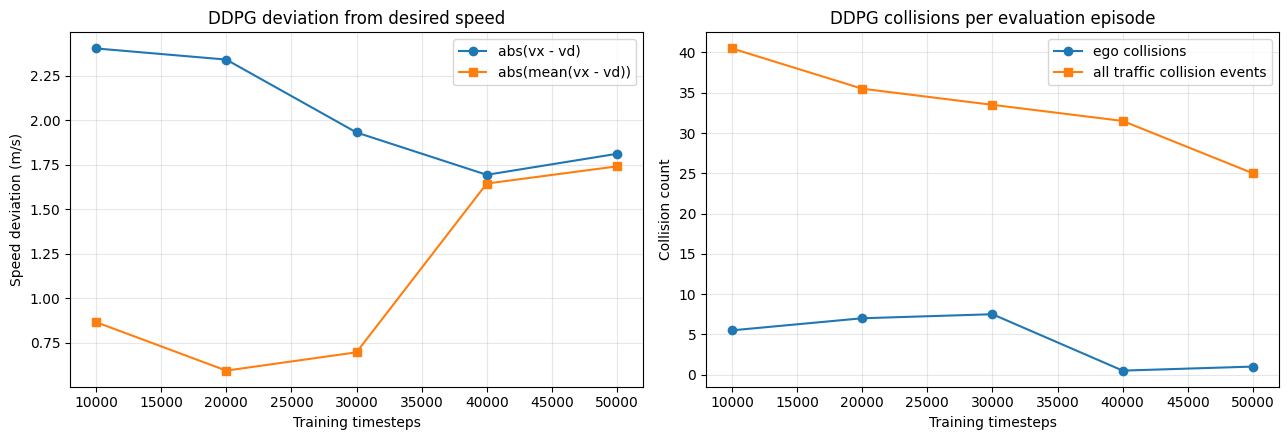

Saved DDPG plot to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
DDPG_HISTORY_PATH = globals().get("DDPG_HISTORY_PATH", ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv")
DDPG_PLOT_PATH = globals().get("DDPG_PLOT_PATH", ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png")

if "ddpg_eval_history" not in globals() or ddpg_eval_history.empty:
    ddpg_eval_history = pd.read_csv(DDPG_HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_signed_speed_deviation"].abs(), marker="s", label="abs(mean(vx - vd))")
axes[0].set_title("DDPG deviation from desired speed")
axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Speed deviation (m/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[1].set_title("DDPG collisions per evaluation episode")
axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Collision count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(DDPG_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG plot to", DDPG_PLOT_PATH)

### DDPG Without CBF Final Evaluation

In [21]:
import subprocess

DDPG_FINAL_METRICS_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_final_metrics.csv"
ddpg_eval_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
    "--variant",
    "ddpg",
    "--episodes",
    str(FINAL_EVAL_EPISODES),
    "--seed",
    str(SEED + 60_000),
    "--output",
    str(DDPG_FINAL_METRICS_PATH),
    "--device",
    DEVICE,
    "--project-root",
    str(PROJECT_ROOT),
]
ddpg_eval_result = subprocess.run(
    ddpg_eval_command,
    cwd=str(PROJECT_ROOT),
    text=True,
)
if ddpg_eval_result.returncode != 0:
    raise RuntimeError(f"DDPG final evaluation subprocess failed with exit code {ddpg_eval_result.returncode}")
ddpg_final_metrics = pd.read_csv(DDPG_FINAL_METRICS_PATH)
display(ddpg_final_metrics)
display(ddpg_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,return,mean_speed,mean_signed_speed_deviation,mean_abs_speed_deviation,ego_collisions,ego_collision_steps,total_collision_events
0,0,800,361.945165,18.550849,-1.449151,1.513007,0.0,0.0,27.0
1,1,800,288.047141,18.387822,-1.612178,1.723413,0.0,0.0,36.0
2,2,800,203.806794,18.284839,-1.715161,1.759809,2.0,4.0,28.0
3,3,800,299.599908,18.020792,-1.979208,2.099355,0.0,0.0,21.0
4,4,800,244.794570,18.747811,-1.252189,1.362727,3.0,10.0,38.0
5,5,800,333.328472,18.652872,-1.347128,1.848679,2.0,4.0,45.0
6,6,800,303.100170,18.582849,-1.417151,1.561045,0.0,0.0,35.0
7,7,800,274.774449,18.378247,-1.621753,1.678836,0.0,0.0,30.0
8,8,800,159.498021,18.439599,-1.560401,1.665217,7.0,48.0,50.0
9,9,800,395.479471,18.478004,-1.521996,1.810017,0.0,0.0,31.0


,mean
steps,800.000000
return,269.321400
mean_speed,18.413542
mean_signed_speed_deviation,-1.586458
mean_abs_speed_deviation,1.715912
ego_collisions,1.480000
ego_collision_steps,5.900000
total_collision_events,30.940000


### Render The Trained DDPG Without CBF Policy

Set `RUN_DDPG_RENDER = True` when you want a live highway-env render window.

In [ ]:
RUN_DDPG_RENDER = bool(globals().get("RUN_DDPG_RENDER", False))
DDPG_RENDER_STEPS = int(globals().get("DDPG_RENDER_STEPS", 1_000))

if RUN_DDPG_RENDER:
    import subprocess

    ddpg_render_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "render_laneless_karalakou.py"),
        "--variant",
        "ddpg",
        "--steps",
        str(DDPG_RENDER_STEPS),
        "--seed",
        str(SEED + 109_000),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_render_result = subprocess.run(ddpg_render_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_render_result.returncode != 0:
        raise RuntimeError(f"DDPG render subprocess failed with exit code {ddpg_render_result.returncode}")
else:
    print("Skipped DDPG render. Set RUN_DDPG_RENDER = True to open the render in a separate process.")


## DDPG With CBF In Reward

This section defines a non-differentiable 2D CBF-QP action shield. The policy proposes a raw physical acceleration action, the shield minimally modifies it, and the environment executes the filtered action.

The CBF enters training through the shielded environment and the correction penalty in the reward. The DDPG actor and critic losses remain the standard DDPG losses.

### Safety Shield

#### QP Solver Dependencies

In [23]:
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except ImportError as exc:
    raise ImportError("Install CBF-QP dependencies first: !python -m pip install qpsolvers osqp") from exc

#### Barrier Geometry And Hyperparameters

In [24]:
CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_TARGET_PAIR_DY = 3.0
CBF_REFERENCE_EGO_WIDTH = float(ENV_CONFIG["ego_dimensions"][1])
CBF_REFERENCE_SOCIAL_WIDTH = float(ENV_CONFIG["vehicle_dimensions"][0][1])
CBF_EPS_SIDE = max(
    (CBF_TARGET_PAIR_DY - (CBF_REFERENCE_EGO_WIDTH + CBF_REFERENCE_SOCIAL_WIDTH) / np.sqrt(2.0)) / 4.0,
    0.0,
)
CBF_K0 = 2.0
CBF_K1 = 4.0
CBF_NEIGHBOR_RANGE = float(ENV_CONFIG["sensing_range"])
CBF_FILTER_REWARD_LAMBDA = 0.05
CBF_QP_FEASIBILITY_TOL = 1e-6


def inflated_ellipse_axes(length: float, width: float, eps_side: float = CBF_EPS_SIDE) -> tuple[float, float]:
    """Inflated ellipse semi-axes that cover a rectangular vehicle footprint."""
    a = float(length) / np.sqrt(2.0) + 2.0 * float(eps_side)
    b = float(width) / np.sqrt(2.0) + 2.0 * float(eps_side)
    return max(float(a), 1e-6), max(float(b), 1e-6)


def _wrap_angle(angle: float) -> float:
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)


def ellipse_radius_along_line(a: float, b: float, delta: float) -> float:
    """Radius from ellipse center to boundary along a ray at angle delta from major axis."""
    cos_delta = np.cos(float(delta))
    sin_delta = np.sin(float(delta))
    denom = np.sqrt((float(b) * cos_delta) ** 2 + (float(a) * sin_delta) ** 2)
    return float(float(a) * float(b) / max(float(denom), 1e-9))


def pairwise_centerline_clearance(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: Optional[float] = None,
) -> tuple[float, float, float, float]:
    r = float(np.linalg.norm(p))
    if r < 1e-9:
        phi = 0.0
    else:
        phi = float(np.arctan2(float(p[1]), float(p[0])))

    a_ego, b_ego = inflated_ellipse_axes(ego["length"], ego["width"], eps_side)
    a_other, b_other = inflated_ellipse_axes(other["length"], other["width"], eps_side)
    l_ego = ellipse_radius_along_line(a_ego, b_ego, _wrap_angle(phi - float(ego.get("heading", 0.0))))
    l_other = ellipse_radius_along_line(a_other, b_other, _wrap_angle(phi - float(other.get("heading", 0.0))))
    required_distance = l_ego + l_other
    h = r - required_distance
    return float(h), float(r), float(l_ego), float(l_other)




def _wrapped_signed_dx(raw_dx: float, road_length: Optional[float] = None) -> float:
    """Shortest signed longitudinal distance on the ring road, in meters."""
    dx = float(raw_dx)
    if road_length is None:
        return dx
    length = float(road_length)
    if not np.isfinite(length) or length <= 0.0:
        return dx
    return float(((dx + 0.5 * length) % length) - 0.5 * length)


def pairwise_relative_state(ego: dict[str, float], other: dict[str, float]) -> tuple[float, float, float, float]:
    """Relative physical state: neighbor relative to ego, with wrapped ring-road dx."""
    if "signed_dx" in other:
        dx = float(other["signed_dx"])
    else:
        road_length = other.get("road_length", ego.get("road_length"))
        dx = _wrapped_signed_dx(float(other["x"]) - float(ego["x"]), road_length)
    dy = float(other["y"]) - float(ego["y"])
    dvx = float(other["vx"]) - float(ego["vx"])
    dvy = float(other["vy"]) - float(ego["vy"])
    return float(dx), float(dy), float(dvx), float(dvy)


def pairwise_cbf_geometry(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
) -> tuple[float, float, float, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    h, center_distance, l_ego, l_other = pairwise_centerline_clearance(
        np.asarray([dx, dy], dtype=float),
        ego,
        other,
        eps_side,
    )
    required_distance = l_ego + l_other
    return float(h), dx, dy, dvx, dvy, float(center_distance), float(required_distance)


def centerline_barrier_derivatives(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    fd_step: float = 1e-3,
) -> tuple[float, np.ndarray, np.ndarray, float, float, float]:
    p = np.asarray(p, dtype=float).reshape(2)

    def f(point: np.ndarray) -> tuple[float, float, float, float]:
        return pairwise_centerline_clearance(point, ego, other, eps_side)

    h0, center_distance, l_ego, l_other = f(p)
    e_x = np.asarray([fd_step, 0.0], dtype=float)
    e_y = np.asarray([0.0, fd_step], dtype=float)
    h_px = f(p + e_x)[0]
    h_mx = f(p - e_x)[0]
    h_py = f(p + e_y)[0]
    h_my = f(p - e_y)[0]
    grad = np.asarray([(h_px - h_mx) / (2.0 * fd_step), (h_py - h_my) / (2.0 * fd_step)], dtype=float)
    h_pp = f(p + e_x + e_y)[0]
    h_pm = f(p + e_x - e_y)[0]
    h_mp = f(p - e_x + e_y)[0]
    h_mm = f(p - e_x - e_y)[0]
    hessian = np.asarray(
        [
            [(h_px - 2.0 * h0 + h_mx) / (fd_step**2), (h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2)],
            [(h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2), (h_py - 2.0 * h0 + h_my) / (fd_step**2)],
        ],
        dtype=float,
    )
    return float(h0), grad, hessian, float(center_distance), float(l_ego), float(l_other)


def pairwise_hocbf_constraint(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    other_acc: Optional[np.ndarray] = None,
) -> tuple[np.ndarray, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    p = np.asarray([dx, dy], dtype=float)
    v = np.asarray([dvx, dvy], dtype=float)
    a_j = np.zeros(2, dtype=float) if other_acc is None else np.asarray(other_acc, dtype=float).reshape(-1)[:2]
    h, grad, hessian, center_distance, l_ego, l_other = centerline_barrier_derivatives(p, ego, other, eps_side)
    h_dot = float(grad @ v)
    A = np.asarray(grad, dtype=float)
    b = float(v.T @ hessian @ v + grad @ a_j + float(k1) * h_dot + float(k0) * h)
    return A, b, float(h), float(center_distance), float(l_ego + l_other)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
) -> tuple[np.ndarray, dict[str, Any]]:
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
    q = -2.0 * a_rl
    G_rows: list[np.ndarray] = []
    h_rows: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        min_h = min(min_h, h_ij)
        min_center_distance = min(min_center_distance, center_distance)
        min_required_distance = min(min_required_distance, required_distance)
        G_rows.append(A)
        h_rows.append(b)
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    G_rows.append(np.asarray([0.0, -1.0], dtype=float))
    h_rows.append(float(k1 * ego_vy + k0 * h_left))
    G_rows.append(np.asarray([0.0, 1.0], dtype=float))
    h_rows.append(float(-k1 * ego_vy + k0 * h_right))

    G = sparse.csc_matrix(np.asarray(G_rows, dtype=float))
    h_vec = np.asarray(h_rows, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    rl_constraint_values = np.asarray(G @ a_rl - h_vec, dtype=float).reshape(-1)
    raw_is_feasible = (
        bool(np.all(rl_constraint_values <= CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl >= lb - CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl <= ub + CBF_QP_FEASIBILITY_TOL))
    )
    qp_error = ""
    if raw_is_feasible:
        qp_success = True
        a_safe = a_rl.copy()
    else:
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message=r"OSQP exited.*")
                solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver="osqp", verbose=False)
        except Exception as exc:
            solution = None
            qp_error = repr(exc)

        qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
        if qp_success:
            a_safe = np.clip(np.asarray(solution, dtype=float), lb, ub)
        else:
            a_safe = np.asarray([float(ax_bounds[0]), 0.0], dtype=float)

    safe_constraint_values = np.asarray(G @ a_safe - h_vec, dtype=float).reshape(-1)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "raw_feasible": bool(raw_is_feasible),
        "max_constraint_violation_rl": float(np.max(rl_constraint_values)) if len(rl_constraint_values) else 0.0,
        "max_constraint_violation_safe": float(np.max(safe_constraint_values)) if len(safe_constraint_values) else 0.0,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info

#### Action Conversion And Vehicle State Helpers

In [25]:
def _lane_free_base(env: gym.Env):
    return env.unwrapped


def _physical_to_normalized_action(env: gym.Env, a_physical: np.ndarray) -> np.ndarray:
    base = _lane_free_base(env)
    bounds = base.config["bounds"]
    physical_bounds = [
        (float(bounds["ax_min"]), float(bounds["ax_max"])),
        (float(bounds["ay_min"]), float(bounds["ay_max"])),
    ]
    normalized = np.zeros(2, dtype=np.float32)
    for index, (value, (low, high)) in enumerate(zip(np.asarray(a_physical, dtype=float), physical_bounds)):
        value = float(np.clip(value, low, high))
        if low < 0.0 < high:
            scale = high if value >= 0.0 else abs(low)
            normalized[index] = value / max(scale, 1e-6)
        else:
            normalized[index] = float(2.0 * (value - low) / max(high - low, 1e-6) - 1.0)
    return np.clip(normalized, -1.0, 1.0)


def get_ego_state(env: gym.Env) -> dict[str, float]:
    base = _lane_free_base(env)
    ego = base.vehicle
    return {
        "x": float(ego.position[0]),
        "y": float(ego.position[1]),
        "vx": float(ego.vx),
        "vy": float(ego.vy),
        "heading": float(ego.heading),
        "length": float(ego.length),
        "width": float(ego.width),
        "road_length": float(base.config["road_length"]),
    }


def get_neighbor_states(env: gym.Env, neighbor_range: Optional[float] = None) -> list[dict[str, float]]:
    base = _lane_free_base(env)
    ego = base.vehicle
    max_range = float(base.config["sensing_range"] if neighbor_range is None else neighbor_range)
    neighbors: list[dict[str, float]] = []

    for index, vehicle in enumerate(base.road.vehicles):
        if vehicle is ego:
            continue
        dx = float(base._signed_distance(ego.position[0], vehicle.position[0]))
        dy = float(vehicle.position[1] - ego.position[1])
        distance = float(np.sqrt(dx * dx + dy * dy))
        if distance > max_range:
            continue

        ax = ay = 0.0
        if len(base._last_accelerations) > index:
            ax = float(base._last_accelerations[index, 0])
            ay = float(base._last_accelerations[index, 1])

        neighbors.append(
            {
                "x": float(ego.position[0] + dx),
                "y": float(vehicle.position[1]),
                "vx": float(vehicle.vx),
                "vy": float(vehicle.vy),
                "heading": float(vehicle.heading),
                "ax": ax,
                "ay": ay,
                "length": float(vehicle.length),
                "width": float(vehicle.width),
                "distance": distance,
                "signed_dx": dx,
            }
        )

    return sorted(neighbors, key=lambda item: item["distance"])

#### Safety Filter Environment Wrapper

In [26]:
class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Non-differentiable CBF-QP action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        reward = float(reward) - self.lambda_filter * correction_norm**2

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_raw_feasible": bool(filter_info.get("raw_feasible", False)),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(self.lambda_filter * correction_norm**2),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=active_eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )

#### Tuned No-Slack Shield Override

In [27]:
# Tuned DDPG-CBF shield overrides, no slack
# Run this cell after the base CBF definitions and before DDPG-CBF training/evaluation.
# It intentionally overrides cbf_filter_2d, SafetyFilteredAccelerationWrapper, and make_cbf_*_env.
# The CBF gains come from the shared hyperparameter cell above.

# Import the QP dependencies here too, so this override fails loudly if they are missing.
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except ImportError as exc:
    raise ImportError("Install CBF-QP dependencies first: !python -m pip install qpsolvers osqp") from exc

CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_MAX_NEIGHBOR_CONSTRAINTS = 12
CBF_QP_SOLVER = "osqp"
CBF_QP_FEASIBILITY_TOL = 1e-6


def _cbf_emergency_fallback_action(
    a_rl: np.ndarray,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
) -> np.ndarray:
    """Rare solver-failure fallback. Prefer evasive direction over blind straight braking."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    action = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)

    scored_neighbors: list[tuple[float, dict[str, float], float, float, float, float]] = []
    for neighbor in neighbors:
        h, dx, dy, dvx, dvy, _, _ = pairwise_cbf_geometry(ego, neighbor, eps_side=eps_side)
        scored_neighbors.append((float(h), neighbor, float(dx), float(dy), float(dvx), float(dvy)))

    if scored_neighbors:
        h, _, dx, dy, dvx, dvy = min(scored_neighbors, key=lambda item: item[0])
        p = np.asarray([dx, dy], dtype=float)
        v = np.asarray([dvx, dvy], dtype=float)
        closing_speed = float(-(p @ v) / max(float(np.linalg.norm(p)), 1e-6))

        if h < 2.0 and dx > 0.0 and closing_speed > 0.0:
            action[0] = min(action[0], float(ax_bounds[0]))
        if h < 1.0 and abs(dy) > 1e-6:
            action[1] = float(ay_bounds[0] if dy > 0.0 else ay_bounds[1])

    ego_y = float(ego["y"])
    ego_half_width = 0.5 * float(ego["width"])
    if ego_y - ego_half_width < 0.5:
        action[1] = max(action[1], 0.0)
    if float(road_width) - ego_half_width - ego_y < 0.5:
        action[1] = min(action[1], 0.0)

    return np.clip(action, lb, ub).astype(np.float32)


def _least_violating_bounded_action(
    a_rl: np.ndarray,
    constraint_rows: list[np.ndarray],
    constraint_bounds: list[float],
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
) -> np.ndarray:
    """Fallback for infeasible hard-QP states: choose the bounded action with smallest violation."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    target = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)
    rows = np.asarray(constraint_rows, dtype=float)
    bounds = np.asarray(constraint_bounds, dtype=float)

    ax_grid = np.unique(np.r_[np.linspace(lb[0], ub[0], 25), target[0], lb[0], ub[0]])
    ay_grid = np.unique(np.r_[np.linspace(lb[1], ub[1], 25), target[1], lb[1], ub[1]])

    best_action = target.copy()
    best_score: tuple[float, float, float] | None = None
    for ax in ax_grid:
        for ay in ay_grid:
            candidate = np.asarray([ax, ay], dtype=float)
            violations = rows @ candidate - bounds
            positive = np.maximum(violations, 0.0)
            max_violation = float(np.max(positive)) if positive.size else 0.0
            total_violation = float(np.sum(positive**2))
            correction = float(np.sum((candidate - target) ** 2))
            score = (max_violation, total_violation, correction)
            if best_score is None or score < best_score:
                best_score = score
                best_action = candidate

    return np.clip(best_action, lb, ub).astype(np.float32)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
) -> tuple[np.ndarray, dict[str, Any]]:
    """Hard HOCBF-QP filter over physical acceleration actions using tuned gains."""
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    if max_neighbor_constraints is not None:
        neighbors = list(neighbors)[: int(max_neighbor_constraints)]

    constraint_rows: list[np.ndarray] = []
    constraint_bounds: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        constraint_rows.append(np.asarray(A, dtype=float))
        constraint_bounds.append(float(b))
        min_h = min(min_h, float(h_ij))
        min_center_distance = min(min_center_distance, float(center_distance))
        min_required_distance = min(min_required_distance, float(required_distance))
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    # h_left = y - b:    ay + k1*vy + k0*h_left >= 0 -> -ay <= k1*vy + k0*h_left
    # h_right = W-b-y: -ay - k1*vy + k0*h_right >= 0 ->  ay <= -k1*vy + k0*h_right
    constraint_rows.append(np.asarray([0.0, -1.0], dtype=float))
    constraint_bounds.append(float(k1 * ego_vy + k0 * h_left))
    constraint_rows.append(np.asarray([0.0, 1.0], dtype=float))
    constraint_bounds.append(float(-k1 * ego_vy + k0 * h_right))

    P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
    q = -2.0 * a_rl
    G = sparse.csc_matrix(np.asarray(constraint_rows, dtype=float))
    h_vec = np.asarray(constraint_bounds, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    rl_constraint_values = np.asarray(G @ a_rl - h_vec, dtype=float).reshape(-1)
    raw_is_feasible = (
        bool(np.all(rl_constraint_values <= CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl >= lb - CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl <= ub + CBF_QP_FEASIBILITY_TOL))
    )
    qp_error = ""
    if raw_is_feasible:
        qp_success = True
        a_safe = a_rl.copy()
    else:
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message=r"OSQP exited.*")
                solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver=CBF_QP_SOLVER, verbose=False)
        except Exception as exc:
            solution = None
            qp_error = repr(exc)

        qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
        if qp_success:
            a_safe = np.clip(np.asarray(solution, dtype=float).reshape(-1)[:2], lb, ub)
        else:
            a_safe = _least_violating_bounded_action(a_rl, constraint_rows, constraint_bounds, ax_bounds, ay_bounds)
            emergency_action = _cbf_emergency_fallback_action(a_rl, ego, neighbors, road_width, ax_bounds, ay_bounds, eps_side)
            current_violation = max(
                float(np.max(np.maximum(np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
                0.0,
            )
            emergency_violation = max(
                float(np.max(np.maximum(np.asarray([row @ emergency_action - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
                0.0,
            )
            if emergency_violation + 1e-9 < current_violation:
                a_safe = emergency_action

    rl_constraint_values = np.asarray([row @ a_rl - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)
    safe_constraint_values = np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "raw_feasible": bool(raw_is_feasible),
        "max_constraint_violation_rl": float(np.max(rl_constraint_values)) if len(rl_constraint_values) else 0.0,
        "max_constraint_violation_safe": float(np.max(safe_constraint_values)) if len(safe_constraint_values) else 0.0,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "k0": float(k0),
        "k1": float(k1),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info


class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Tuned no-slack DDPG-CBF action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
        max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.max_neighbor_constraints = max_neighbor_constraints
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
            max_neighbor_constraints=self.max_neighbor_constraints,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        correction_penalty = self.lambda_filter * correction_norm**2
        reward = float(reward) - correction_penalty

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_raw_feasible": bool(filter_info.get("raw_feasible", False)),
                "cbf_max_constraint_violation_rl": float(filter_info["max_constraint_violation_rl"]),
                "cbf_max_constraint_violation_safe": float(filter_info["max_constraint_violation_safe"]),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_k0": float(filter_info["k0"]),
                "cbf_k1": float(filter_info["k1"]),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(correction_penalty),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=active_eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


print(
    "Tuned no-slack CBF override active:",
    {
        "k0": CBF_K0,
        "k1": CBF_K1,
        "correction_reward_lambda": CBF_FILTER_REWARD_LAMBDA,
        "max_neighbor_constraints": CBF_MAX_NEIGHBOR_CONSTRAINTS,
    },
)


Tuned no-slack CBF override active: {'k0': 2.0, 'k1': 4.0, 'correction_reward_lambda': 0.05, 'max_neighbor_constraints': 12}


### DDPG-CBF Evaluation Helpers

These metrics evaluate a policy through the shielded environment and log intervention behavior in addition to reward, speed tracking, and collisions.

In [28]:
def evaluate_cbf_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 40_000,
    deterministic: bool = True,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_cbf_single_env(
            seed=seed + episode,
            lambda_filter=lambda_filter,
            eps_side=CBF_EPS_SIDE if eps_side is None else float(eps_side),
            env_config=env_config,
            reward_config=reward_config,
        )
        configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        corrections = []
        interventions = []
        qp_successes = []
        min_h_values = []
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            correction = float(info.get("cbf_correction_norm", 0.0))
            event_threshold = float(info.get("cbf_event_intervention_threshold", 0.03))
            corrections.append(correction)
            interventions.append(float(info.get("cbf_event_intervened", correction > event_threshold)))
            qp_successes.append(float(info.get("cbf_qp_success", True)))
            min_h_values.append(float(info.get("cbf_min_h", np.nan)))
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        rows.append(
            {
                "episode": episode,
                "steps": step_count,
                "return": float(np.sum(rewards)),
                "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
                "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
                "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
                "ego_collisions": float(ego_collisions),
                "ego_collision_steps": float(ego_collision_steps),
                "total_collision_events": float(all_collision_events),
                "mean_correction_norm": float(np.mean(corrections)) if corrections else 0.0,
                "max_correction_norm": float(np.max(corrections)) if corrections else 0.0,
                "intervention_rate": float(np.mean(interventions)) if interventions else 0.0,
                "qp_failure_rate": float(1.0 - np.mean(qp_successes)) if qp_successes else 0.0,
                "min_h": float(np.nanmin(min_h_values)) if min_h_values and not np.all(np.isnan(min_h_values)) else np.nan,
            }
        )
        env.close()
    return pd.DataFrame(rows)


class CBFEvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, lambda_filter: float, eps_side: Optional[float] = None, tb_prefix: str = "eval/cbf", verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.lambda_filter = float(lambda_filter)
        self.eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
        self.tb_prefix = str(tb_prefix)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_cbf_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
            lambda_filter=self.lambda_filter,
            eps_side=self.eps_side,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
            "mean_correction_norm": float(metrics["mean_correction_norm"].mean()),
            "intervention_rate": float(metrics["intervention_rate"].mean()),
            "qp_failure_rate": float(metrics["qp_failure_rate"].mean()),
            "min_h": float(metrics["min_h"].min()),
        }
        self.records.append(row)
        if "record_tensorboard_row" in globals():
            record_tensorboard_row(self.logger, self.tb_prefix, row, step=self.num_timesteps)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"intervention={row['intervention_rate']:.2%} | "
                f"qp failures={row['qp_failure_rate']:.2%} | "
                f"ego collisions={row['ego_collisions']:.2f}"
            )
        return True

### Train DDPG-CBF With Reward Penalty

Train DDPG inside the shielded environment. The policy observes the same flat 42D legacy vehicle-table state as the baseline DDPG and outputs raw physical acceleration actions; the non-differentiable CBF-QP shield filters them before execution.

In [ ]:
RUN_DDPG_CBF_TRAIN = bool(globals().get("RUN_DDPG_CBF_TRAIN", False))
RUN_DDPG_CBF_TRAIN_SUBPROCESS = bool(globals().get("RUN_DDPG_CBF_TRAIN_SUBPROCESS", False))

if RUN_DDPG_CBF_TRAIN_SUBPROCESS:
    import subprocess

    ddpg_cbf_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "ddpg-cbf-train",
        "--timesteps",
        str(DDPG_CBF_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_CBF_NUM_ENVS),
        "--lambda-filter",
        str(CBF_FILTER_REWARD_LAMBDA),
        "--k0",
        str(CBF_K0),
        "--k1",
        str(CBF_K1),
        "--eps-side",
        str(CBF_EPS_SIDE),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_cbf_train_result = subprocess.run(ddpg_cbf_train_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_cbf_train_result.returncode != 0:
        raise RuntimeError(f"DDPG-CBF training subprocess failed with exit code {ddpg_cbf_train_result.returncode}")
elif RUN_DDPG_CBF_TRAIN:
    ddpg_cbf_train_env = make_cbf_training_env(
        seed=SEED,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        n_envs=DDPG_CBF_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    ddpg_cbf_n_envs = int(getattr(ddpg_cbf_train_env, "num_envs", 1))
    n_actions = ddpg_cbf_train_env.action_space.shape[-1]
    ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_cbf_n_envs)
    ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 70_000,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        tb_prefix="eval/DDPG_CBF_reward",
    )
    ddpg_cbf_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG-CBF reward",
        step_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_training_episode_trace.csv",
    )
    ddpg_cbf_training_callback = callback_list_with_tensorboard(
        "DDPG-CBF reward",
        ddpg_cbf_eval_callback,
        ddpg_cbf_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": True, "actor_loss": False, "env_kind": "current"},
    )
    print(f"DDPG-CBF training envs: {ddpg_cbf_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    ddpg_cbf_model = DDPG(
        "MlpPolicy",
        ddpg_cbf_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=1,
        action_noise=ddpg_cbf_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
    )

    start_time = time.time()
    ddpg_cbf_model.learn(total_timesteps=DDPG_CBF_TOTAL_TIMESTEPS, callback=ddpg_cbf_training_callback, progress_bar=False)
    ddpg_cbf_elapsed = time.time() - start_time

    ddpg_cbf_model.save(str(DDPG_CBF_MODEL_PATH))
    ddpg_cbf_train_env.close()

    ddpg_cbf_eval_history = pd.DataFrame(ddpg_cbf_eval_callback.records)
    ddpg_cbf_eval_history.to_csv(DDPG_CBF_HISTORY_PATH, index=False)
    print(f"Saved DDPG-CBF model to {DDPG_CBF_MODEL_PATH}")
    print(f"Saved DDPG-CBF eval history to {DDPG_CBF_HISTORY_PATH}")
    print(f"Saved DDPG-CBF stepwise trace to {ddpg_cbf_stepwise_callback.step_trace_path}")
    print(f"Saved DDPG-CBF episode trace to {ddpg_cbf_stepwise_callback.episode_trace_path}")
    print(f"DDPG-CBF training time: {ddpg_cbf_elapsed / 60:.1f} min")
    display(ddpg_cbf_eval_history)
else:
    print("Skipped DDPG-CBF training in the notebook kernel. Set RUN_DDPG_CBF_TRAIN_SUBPROCESS = True to train safely out of process.")


### Plot DDPG-CBF Reward-Penalty Training Results

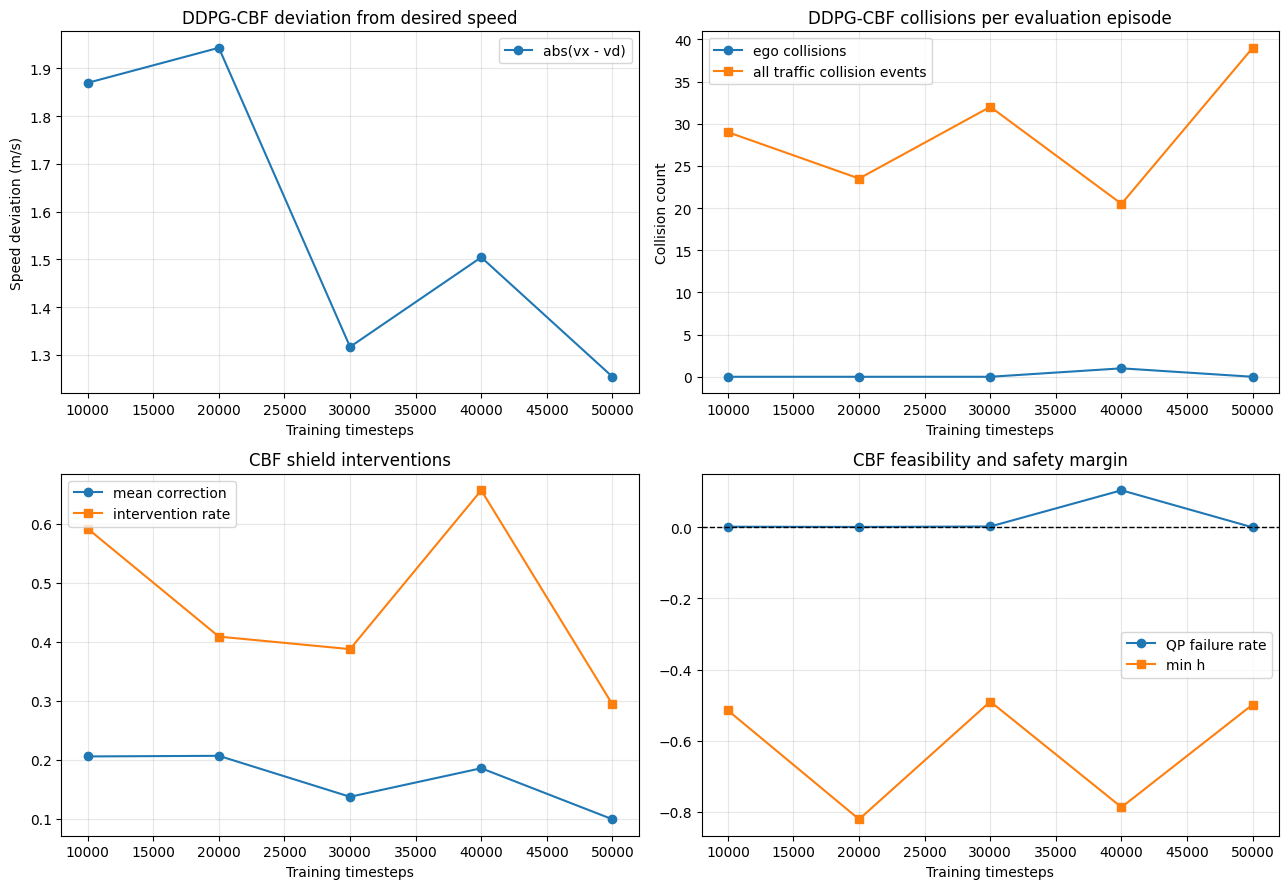

Saved DDPG-CBF plot to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
DDPG_CBF_HISTORY_PATH = globals().get("DDPG_CBF_HISTORY_PATH", ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv")
DDPG_CBF_PLOT_PATH = globals().get("DDPG_CBF_PLOT_PATH", ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png")

if "ddpg_cbf_eval_history" not in globals() or ddpg_cbf_eval_history.empty:
    ddpg_cbf_eval_history = pd.read_csv(DDPG_CBF_HISTORY_PATH)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0, 0].set_title("DDPG-CBF deviation from desired speed")
axes[0, 0].set_xlabel("Training timesteps")
axes[0, 0].set_ylabel("Speed deviation (m/s)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[0, 1].set_title("DDPG-CBF collisions per evaluation episode")
axes[0, 1].set_xlabel("Training timesteps")
axes[0, 1].set_ylabel("Collision count")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_correction_norm"], marker="o", label="mean correction")
axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["intervention_rate"], marker="s", label="intervention rate")
axes[1, 0].set_title("CBF shield interventions")
axes[1, 0].set_xlabel("Training timesteps")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["qp_failure_rate"], marker="o", label="QP failure rate")
axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["min_h"], marker="s", label="min h")
axes[1, 1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1, 1].set_title("CBF feasibility and safety margin")
axes[1, 1].set_xlabel("Training timesteps")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(DDPG_CBF_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG-CBF plot to", DDPG_CBF_PLOT_PATH)

### DDPG-CBF Reward-Penalty Final Evaluation

In [30]:
import subprocess

DDPG_CBF_FINAL_METRICS_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_final_metrics.csv"
ddpg_cbf_eval_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
    "--variant",
    "ddpg-cbf",
    "--episodes",
    str(FINAL_EVAL_EPISODES),
    "--seed",
    str(SEED + 90_000),
    "--output",
    str(DDPG_CBF_FINAL_METRICS_PATH),
    "--device",
    DEVICE,
    "--project-root",
    str(PROJECT_ROOT),
]
ddpg_cbf_eval_result = subprocess.run(
    ddpg_cbf_eval_command,
    cwd=str(PROJECT_ROOT),
    text=True,
)
if ddpg_cbf_eval_result.returncode != 0:
    raise RuntimeError(f"DDPG-CBF final evaluation subprocess failed with exit code {ddpg_cbf_eval_result.returncode}")
ddpg_cbf_final_metrics = pd.read_csv(DDPG_CBF_FINAL_METRICS_PATH)
display(ddpg_cbf_final_metrics)
display(ddpg_cbf_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,return,mean_speed,mean_signed_speed_deviation,mean_abs_speed_deviation,ego_collisions,ego_collision_steps,total_collision_events,mean_correction_norm,max_correction_norm,intervention_rate,qp_failure_rate,min_h
0,0,800,276.358511,18.907269,-1.092731,1.184735,0.0,0.0,33.0,0.294750,5.645740,0.70125,0.16875,-0.853376
1,1,800,204.633142,18.400522,-1.599478,1.635855,0.0,0.0,14.0,0.264003,1.108450,0.79750,0.12750,-0.907743
2,2,800,256.753741,18.352458,-1.647542,1.832085,0.0,0.0,45.0,0.265461,3.045888,0.57375,0.08125,-0.576522
3,3,800,220.724077,18.564240,-1.435760,1.474469,0.0,0.0,40.0,0.346311,3.268098,0.84875,0.29750,-1.045648
4,4,800,240.095945,18.362916,-1.637084,1.653720,0.0,0.0,22.0,0.385385,3.701615,0.81875,0.15875,-0.861313
5,5,800,285.076302,18.633114,-1.366886,1.393724,0.0,0.0,18.0,0.214555,2.083622,0.45750,0.12625,-0.755796
6,6,800,275.078223,18.898769,-1.101231,1.173104,0.0,0.0,33.0,0.270444,3.506757,0.50500,0.12875,-1.263294
7,7,800,221.732723,19.346730,-0.653270,0.844240,0.0,0.0,17.0,0.280398,2.042407,0.67750,0.18000,-0.808810
8,8,800,192.971036,18.691518,-1.308482,1.324877,0.0,0.0,27.0,0.245706,2.915247,0.82000,0.00000,-0.338283
9,9,800,181.976118,18.350766,-1.649234,1.658553,1.0,2.0,30.0,0.283016,4.715888,0.74375,0.10000,-1.622424


,mean
steps,800.000000
return,243.410265
mean_speed,18.771662
mean_signed_speed_deviation,-1.228338
mean_abs_speed_deviation,1.382347
ego_collisions,0.360000
ego_collision_steps,3.700000
total_collision_events,28.880000
mean_correction_norm,0.287838
max_correction_norm,2.820369


### Render The Trained DDPG-CBF Reward-Penalty Policy

Set `RUN_DDPG_CBF_RENDER = True` when you want a live highway-env render window. Run the tuned no-slack CBF override cell before this render cell so the shielded environment matches training.

In [ ]:
RUN_DDPG_CBF_RENDER = bool(globals().get("RUN_DDPG_CBF_RENDER", False))
DDPG_CBF_RENDER_STEPS = int(globals().get("DDPG_CBF_RENDER_STEPS", 1_000))

if RUN_DDPG_CBF_RENDER:
    import subprocess

    ddpg_cbf_render_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "render_laneless_karalakou.py"),
        "--variant",
        "ddpg-cbf",
        "--steps",
        str(DDPG_CBF_RENDER_STEPS),
        "--seed",
        str(SEED + 119_000),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_cbf_render_result = subprocess.run(ddpg_cbf_render_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_cbf_render_result.returncode != 0:
        raise RuntimeError(f"DDPG-CBF render subprocess failed with exit code {ddpg_cbf_render_result.returncode}")
else:
    print("Skipped DDPG-CBF render. Set RUN_DDPG_CBF_RENDER = True to open the render in a separate process.")


## DDPG With CBF In Reward And Loss

This guided variant keeps the CBF shield and reward penalty from the previous section, then adds a CBF-informed term to the actor update. Successful shield interventions are stored in the replay buffer, and the actor receives an extra imitation-style loss that nudges raw actions toward safe CBF-filtered actions.

### Guided CBF Loss And Training

#### Loss Add-On

The standard DDPG actor loss is combined with a weighted behavior-cloning penalty on successful CBF interventions. This is the notebook's reward-plus-loss CBF formulation.

In [ ]:
# Guided DDPG-CBF actor update with successful-CBF imitation.
# Run this after the tuned no-slack CBF override and CBF evaluation helper cells.

from typing import Any, NamedTuple, Optional

import torch as th
import torch.nn.functional as F
from stable_baselines3.common.buffers import ReplayBuffer
from stable_baselines3.common.utils import polyak_update


GUIDED_CBF_LAMBDA_BC = 0.10
GUIDED_CBF_BC_DELTA = 0.03
GUIDED_CBF_ACTION_SCALE = 1.0
GUIDED_CBF_WEIGHT_MAX = 5.0
GUIDED_CBF_INTERVENTION_THRESHOLD = 0.03
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = DDPG_CBF_TOTAL_TIMESTEPS

GUIDED_DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
GUIDED_DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"


class GuidedSafetyFilteredAccelerationWrapper(SafetyFilteredAccelerationWrapper):
    """CBF shield wrapper that exposes training-ready raw/safe action metadata."""

    def __init__(self, *args, intervention_threshold: float = GUIDED_CBF_INTERVENTION_THRESHOLD, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.intervention_threshold = float(intervention_threshold)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        info = dict(info)

        raw_action = np.asarray(
            [info.get("cbf_a_rl_x", 0.0), info.get("cbf_a_rl_y", 0.0)],
            dtype=np.float32,
        )
        safe_action = np.asarray(
            [info.get("cbf_a_safe_x", raw_action[0]), info.get("cbf_a_safe_y", raw_action[1])],
            dtype=np.float32,
        )
        correction_norm = float(info.get("cbf_correction_norm", np.linalg.norm(safe_action - raw_action)))
        meaningful_correction_norm = float(max(correction_norm - self.intervention_threshold, 0.0))
        raw_norm_penalty = float(info.get("cbf_filter_reward_penalty", self.lambda_filter * correction_norm**2))
        norm_penalty = float(self.lambda_filter * meaningful_correction_norm**2)
        reward = float(reward) + raw_norm_penalty - norm_penalty
        qp_success = bool(info.get("cbf_qp_success", True))
        fallback_used = bool(info.get("cbf_fallback_used", not qp_success))
        intervention = bool(correction_norm > self.intervention_threshold)

        # Keep the existing cbf_* keys for old evaluation code and add compact aliases for replay-buffer storage.
        info.update(
            {
                "raw_action_phys": raw_action,
                "safe_action_phys": safe_action,
                "correction_norm": correction_norm,
                "intervention": intervention,
                "cbf_event_intervened": intervention,
                "cbf_event_intervention_threshold": float(self.intervention_threshold),
                "meaningful_correction_norm": meaningful_correction_norm,
                "cbf_meaningful_correction_norm": meaningful_correction_norm,
                "cbf_filter_raw_norm_reward_penalty": raw_norm_penalty,
                "cbf_filter_norm_reward_penalty": norm_penalty,
                "cbf_filter_reward_penalty": norm_penalty,
                "qp_success": qp_success,
                "fallback_used": fallback_used,
            }
        )
        return obs, reward, terminated, truncated, info


def make_guided_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = GuidedSafetyFilteredAccelerationWrapper(
        env,
        lambda_filter=lambda_filter,
        eps_side=active_eps_side,
        k0=CBF_K0,
        k1=CBF_K1,
        intervention_threshold=GUIDED_CBF_INTERVENTION_THRESHOLD,
    )
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_guided_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_guided_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


class CBFGuidedReplayBufferSamples(NamedTuple):
    observations: th.Tensor
    actions: th.Tensor
    next_observations: th.Tensor
    dones: th.Tensor
    rewards: th.Tensor
    raw_actions: th.Tensor
    safe_actions: th.Tensor
    correction_norms: th.Tensor
    scaled_correction_norms: th.Tensor
    interventions: th.Tensor
    qp_successes: th.Tensor
    fallback_used: th.Tensor


class CBFGuidedReplayBuffer(ReplayBuffer):
    """Replay buffer that keeps CBF correction metadata beside SB3-scaled actions."""

    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        action_shape = (self.buffer_size, self.n_envs, self.action_dim)
        scalar_shape = (self.buffer_size, self.n_envs, 1)
        self.raw_actions = np.zeros(action_shape, dtype=np.float32)
        self.safe_actions = np.zeros(action_shape, dtype=np.float32)
        self.correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.scaled_correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.interventions = np.zeros(scalar_shape, dtype=np.float32)
        self.qp_successes = np.ones(scalar_shape, dtype=np.float32)
        self.fallback_used = np.zeros(scalar_shape, dtype=np.float32)

    @staticmethod
    def _read_action(info: dict[str, Any], array_key: str, x_key: str, y_key: str) -> Optional[np.ndarray]:
        if array_key in info:
            action = np.asarray(info[array_key], dtype=np.float32).reshape(-1)
        elif x_key in info and y_key in info:
            action = np.asarray([info[x_key], info[y_key]], dtype=np.float32)
        else:
            return None
        if action.size < 2 or not np.all(np.isfinite(action[:2])):
            return None
        return action[:2].astype(np.float32)

    def _to_actor_scale(self, action_phys: np.ndarray) -> np.ndarray:
        low = np.asarray(self.action_space.low, dtype=np.float32).reshape(-1)[: self.action_dim]
        high = np.asarray(self.action_space.high, dtype=np.float32).reshape(-1)[: self.action_dim]
        action_phys = np.asarray(action_phys, dtype=np.float32).reshape(-1)[: self.action_dim]
        scaled = 2.0 * ((np.clip(action_phys, low, high) - low) / np.maximum(high - low, 1e-6)) - 1.0
        return np.clip(scaled, -1.0, 1.0).astype(np.float32)

    def add(self, obs, next_obs, action, reward, done, infos) -> None:
        slot = self.pos
        raw_actions_scaled = np.asarray(action, dtype=np.float32).reshape((self.n_envs, self.action_dim))
        self.raw_actions[slot] = raw_actions_scaled

        for env_idx, info in enumerate(infos):
            raw_phys = self._read_action(info, "raw_action_phys", "cbf_a_rl_x", "cbf_a_rl_y")
            raw_scaled = raw_actions_scaled[env_idx] if raw_phys is None else self._to_actor_scale(raw_phys)
            safe_phys = self._read_action(info, "safe_action_phys", "cbf_a_safe_x", "cbf_a_safe_y")
            safe_scaled = raw_scaled.copy() if safe_phys is None else self._to_actor_scale(safe_phys)

            self.raw_actions[slot, env_idx] = raw_scaled
            self.safe_actions[slot, env_idx] = safe_scaled
            correction_norm = float(info.get("correction_norm", info.get("cbf_correction_norm", 0.0)))
            self.correction_norms[slot, env_idx, 0] = correction_norm
            self.scaled_correction_norms[slot, env_idx, 0] = float(np.linalg.norm(safe_scaled - raw_scaled))
            qp_success = bool(info.get("qp_success", info.get("cbf_qp_success", True)))
            fallback_used = bool(info.get("fallback_used", not qp_success))
            threshold = float(info.get("cbf_event_intervention_threshold", GUIDED_CBF_INTERVENTION_THRESHOLD))
            intervention = bool(info.get("cbf_event_intervened", info.get("intervention", correction_norm > threshold)))
            self.interventions[slot, env_idx, 0] = float(intervention)
            self.qp_successes[slot, env_idx, 0] = float(qp_success)
            self.fallback_used[slot, env_idx, 0] = float(fallback_used)

        super().add(obs, next_obs, action, reward, done, infos)

    def _get_samples(self, batch_inds: np.ndarray, env=None) -> CBFGuidedReplayBufferSamples:
        env_indices = np.random.randint(0, high=self.n_envs, size=(len(batch_inds),))
        if self.optimize_memory_usage:
            next_obs = self._normalize_obs(self.observations[(batch_inds + 1) % self.buffer_size, env_indices, :], env)
        else:
            next_obs = self._normalize_obs(self.next_observations[batch_inds, env_indices, :], env)

        data = (
            self._normalize_obs(self.observations[batch_inds, env_indices, :], env),
            self.actions[batch_inds, env_indices, :],
            next_obs,
            (self.dones[batch_inds, env_indices] * (1 - self.timeouts[batch_inds, env_indices])).reshape(-1, 1),
            self._normalize_reward(self.rewards[batch_inds, env_indices].reshape(-1, 1), env),
            self.raw_actions[batch_inds, env_indices, :],
            self.safe_actions[batch_inds, env_indices, :],
            self.correction_norms[batch_inds, env_indices, :],
            self.scaled_correction_norms[batch_inds, env_indices, :],
            self.interventions[batch_inds, env_indices, :],
            self.qp_successes[batch_inds, env_indices, :],
            self.fallback_used[batch_inds, env_indices, :],
        )
        return CBFGuidedReplayBufferSamples(*tuple(map(self.to_torch, data)))


class GuidedCBFDDPG(DDPG):
    """DDPG with unchanged critic loss and CBF-guided actor imitation."""

    def __init__(
        self,
        *args,
        lambda_bc: float = GUIDED_CBF_LAMBDA_BC,
        bc_delta: float = GUIDED_CBF_BC_DELTA,
        bc_action_scale: float = GUIDED_CBF_ACTION_SCALE,
        bc_weight_max: float = GUIDED_CBF_WEIGHT_MAX,
        **kwargs,
    ) -> None:
        if kwargs.get("replay_buffer_class") is None:
            kwargs["replay_buffer_class"] = CBFGuidedReplayBuffer
        self.lambda_bc = float(lambda_bc)
        self.bc_delta = float(bc_delta)
        self.bc_action_scale = float(max(bc_action_scale, 1e-6))
        self.bc_weight_max = float(bc_weight_max)
        super().__init__(*args, **kwargs)

    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        self.policy.set_training_mode(True)
        self._update_learning_rate([self.actor.optimizer, self.critic.optimizer])

        actor_losses, actor_rl_losses, bc_losses, critic_losses = [], [], [], []
        bc_mask_rates, bc_weight_means = [], []

        for _ in range(gradient_steps):
            self._n_updates += 1
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            discounts = getattr(replay_data, "discounts", None)
            if discounts is None:
                discounts = self.gamma

            with th.no_grad():
                noise = replay_data.actions.clone().data.normal_(0, self.target_policy_noise)
                noise = noise.clamp(-self.target_noise_clip, self.target_noise_clip)
                next_actions = (self.actor_target(replay_data.next_observations) + noise).clamp(-1, 1)
                next_q_values = th.cat(self.critic_target(replay_data.next_observations, next_actions), dim=1)
                next_q_values, _ = th.min(next_q_values, dim=1, keepdim=True)
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            current_q_values = self.critic(replay_data.observations, replay_data.actions)
            critic_loss = sum(F.mse_loss(current_q, target_q_values) for current_q in current_q_values)
            assert isinstance(critic_loss, th.Tensor)
            critic_losses.append(critic_loss.item())

            self.critic.optimizer.zero_grad()
            critic_loss.backward()
            self.critic.optimizer.step()

            if self._n_updates % self.policy_delay == 0:
                a_pred = self.actor(replay_data.observations)
                rl_actor_loss = -self.critic.q1_forward(replay_data.observations, a_pred).mean()

                mask = (
                    (replay_data.interventions > 0.5)
                    & (replay_data.qp_successes > 0.5)
                    & (replay_data.fallback_used < 0.5)
                )
                mask_float = mask.float()
                weights = 1.0 + th.clamp(
                    replay_data.scaled_correction_norms / self.bc_action_scale,
                    min=0.0,
                    max=self.bc_weight_max,
                )
                bc_per_sample = ((a_pred - replay_data.safe_actions) ** 2).sum(dim=1, keepdim=True)
                bc_loss = (mask_float * weights * bc_per_sample).sum() / (mask_float.sum() + 1e-6)
                actor_loss = rl_actor_loss + self.lambda_bc * bc_loss

                actor_losses.append(actor_loss.item())
                actor_rl_losses.append(rl_actor_loss.item())
                bc_losses.append(bc_loss.item())
                bc_mask_rates.append(mask_float.mean().item())
                if mask_float.sum().item() > 0.0:
                    bc_weight_means.append((mask_float * weights).sum().item() / (mask_float.sum().item() + 1e-6))
                else:
                    bc_weight_means.append(0.0)

                self.actor.optimizer.zero_grad()
                actor_loss.backward()
                self.actor.optimizer.step()

                polyak_update(self.critic.parameters(), self.critic_target.parameters(), self.tau)
                polyak_update(self.actor.parameters(), self.actor_target.parameters(), self.tau)
                polyak_update(self.critic_batch_norm_stats, self.critic_batch_norm_stats_target, 1.0)
                polyak_update(self.actor_batch_norm_stats, self.actor_batch_norm_stats_target, 1.0)

        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        if actor_losses:
            self.logger.record("train/actor_loss", np.mean(actor_losses))
            self.logger.record("train/actor_rl_loss", np.mean(actor_rl_losses))
            self.logger.record("train/cbf_bc_loss", np.mean(bc_losses))
            self.logger.record("train/cbf_bc_mask_rate", np.mean(bc_mask_rates))
            self.logger.record("train/cbf_bc_weight", np.mean(bc_weight_means))
        self.logger.record("train/critic_loss", np.mean(critic_losses))

RUN_GUIDED_DDPG_CBF_TRAIN = bool(globals().get("RUN_GUIDED_DDPG_CBF_TRAIN", False))
RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS = bool(globals().get("RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS", False))

if RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS:
    import subprocess

    guided_ddpg_cbf_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "guided-ddpg-cbf-train",
        "--timesteps",
        str(GUIDED_DDPG_CBF_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_CBF_NUM_ENVS),
        "--lambda-filter",
        str(CBF_FILTER_REWARD_LAMBDA),
        "--k0",
        str(CBF_K0),
        "--k1",
        str(CBF_K1),
        "--eps-side",
        str(CBF_EPS_SIDE),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    guided_ddpg_cbf_train_result = subprocess.run(guided_ddpg_cbf_train_command, cwd=str(PROJECT_ROOT), text=True)
    if guided_ddpg_cbf_train_result.returncode != 0:
        raise RuntimeError(f"Guided DDPG-CBF training subprocess failed with exit code {guided_ddpg_cbf_train_result.returncode}")
elif RUN_GUIDED_DDPG_CBF_TRAIN:
    guided_ddpg_cbf_train_env = make_guided_cbf_training_env(
        seed=SEED,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        n_envs=DDPG_CBF_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    guided_ddpg_cbf_n_envs = int(getattr(guided_ddpg_cbf_train_env, "num_envs", 1))
    n_actions = guided_ddpg_cbf_train_env.action_space.shape[-1]
    guided_ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=guided_ddpg_cbf_n_envs)
    guided_ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 130_000,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        tb_prefix="eval/DDPG_CBF_reward_loss",
    )
    guided_ddpg_cbf_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG-CBF reward + loss",
        step_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_episode_trace.csv",
    )
    guided_ddpg_cbf_training_callback = callback_list_with_tensorboard(
        "DDPG-CBF reward + loss",
        guided_ddpg_cbf_eval_callback,
        guided_ddpg_cbf_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": True, "actor_loss": True, "env_kind": "current"},
    )
    print(f"Guided DDPG-CBF training envs: {guided_ddpg_cbf_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    guided_ddpg_cbf_model = GuidedCBFDDPG(
        "MlpPolicy",
        guided_ddpg_cbf_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=1,
        action_noise=guided_ddpg_cbf_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
        lambda_bc=GUIDED_CBF_LAMBDA_BC,
        bc_delta=GUIDED_CBF_BC_DELTA,
        bc_action_scale=GUIDED_CBF_ACTION_SCALE,
        bc_weight_max=GUIDED_CBF_WEIGHT_MAX,
    )

    start_time = time.time()
    guided_ddpg_cbf_model.learn(total_timesteps=GUIDED_DDPG_CBF_TOTAL_TIMESTEPS, callback=guided_ddpg_cbf_training_callback, progress_bar=False)
    guided_ddpg_cbf_elapsed = time.time() - start_time

    guided_ddpg_cbf_model.save(str(GUIDED_DDPG_CBF_MODEL_PATH))
    guided_ddpg_cbf_train_env.close()

    guided_ddpg_cbf_eval_history = pd.DataFrame(guided_ddpg_cbf_eval_callback.records)
    guided_ddpg_cbf_eval_history.to_csv(GUIDED_DDPG_CBF_HISTORY_PATH, index=False)
    print(f"Saved guided DDPG-CBF model to {GUIDED_DDPG_CBF_MODEL_PATH}")
    print(f"Saved guided DDPG-CBF eval history to {GUIDED_DDPG_CBF_HISTORY_PATH}")
    print(f"Saved guided DDPG-CBF stepwise trace to {guided_ddpg_cbf_stepwise_callback.step_trace_path}")
    print(f"Saved guided DDPG-CBF episode trace to {guided_ddpg_cbf_stepwise_callback.episode_trace_path}")
    print(f"Guided DDPG-CBF training time: {guided_ddpg_cbf_elapsed / 60:.1f} min")
    display(guided_ddpg_cbf_eval_history)
else:
    print("Skipped guided DDPG-CBF training in the notebook kernel. Set RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS = True to train safely out of process.")


## Smoothed DDPG Training Progress

After retraining the three DDPG variants with the stepwise logger, use this section to compare the raw training stream. The faint background curves are direct environment transitions from training; the thick curves are moving averages over those same timestep rows. This does not use validation/evaluation history or TensorBoard rollout summaries.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
from IPython.display import display

DDPG_EPISODE_BIN_SIZE = 2_500
DDPG_STEP_BIN_SIZE = 2_500
DDPG_SMOOTH_SPAN_BINS = 4
SHOW_DDPG_BIN_POINTS = False
DDPG_EXPECTED_TRAINING_TIMESTEPS = float(globals().get("DDPG_TOTAL_TIMESTEPS", 50_000))
DDPG_TRACE_COMPLETION_FRACTION = 0.95
DDPG_USE_LATEST_TRAINING_REGISTRY = bool(globals().get("DDPG_USE_LATEST_TRAINING_REGISTRY", True))
DDPG_DIRECT_COMBINED_EPISODE_PATH = ARTIFACT_DIR / "ddpg_direct_training_episode_trace_combined.csv"
DDPG_DIRECT_EPISODE_BIN_PATH = ARTIFACT_DIR / "ddpg_direct_training_episode_bins.csv"
DDPG_DIRECT_STEP_BIN_PATH = ARTIFACT_DIR / "ddpg_direct_training_step_reward_bins.csv"
DDPG_DIRECT_PERFORMANCE_PLOT_PATH = ARTIFACT_DIR / "ddpg_direct_training_performance.png"
DDPG_DIRECT_TRACKING_PLOT_PATH = ARTIFACT_DIR / "ddpg_direct_training_tracking_errors.png"
DDPG_DIRECT_CONTROL_PLOT_PATH = ARTIFACT_DIR / "ddpg_direct_training_reward_intervention.png"
DDPG_DIRECT_COMPARISON_PLOT_PATH = ARTIFACT_DIR / "ddpg_direct_training_smoothed_progress.png"
DDPG_DIRECT_LEGACY_COMPARISON_PLOT_PATH = ARTIFACT_DIR / "ddpg_direct_training_episode_progress.png"
DDPG_LATEST_TRAINING_RUNS_PATH = ARTIFACT_DIR / "latest_training_runs.json"

DDPG_SHARED_STEP_TRACE_RUNS = {
    "DDPG without CBF": ARTIFACT_DIR / "ddpg_without_cbf_training_step_trace.csv",
    "DDPG-CBF reward": ARTIFACT_DIR / "ddpg_cbf_reward_training_step_trace.csv",
    "DDPG-CBF reward + loss": ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_step_trace.csv",
}
DDPG_SHARED_EPISODE_TRACE_RUNS = {
    "DDPG without CBF": ARTIFACT_DIR / "ddpg_without_cbf_training_episode_trace.csv",
    "DDPG-CBF reward": ARTIFACT_DIR / "ddpg_cbf_reward_training_episode_trace.csv",
    "DDPG-CBF reward + loss": ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_episode_trace.csv",
}


def _trace_max_timestep(path: Path) -> float:
    if not path.exists():
        return 0.0
    frame = pd.read_csv(path, usecols=lambda column: column in {"global_timestep", "timestep", "sb3_num_timesteps"})
    for column in ["global_timestep", "timestep", "sb3_num_timesteps"]:
        if column in frame.columns:
            values = pd.to_numeric(frame[column], errors="coerce")
            return float(values.max()) if not values.empty else 0.0
    return 0.0


def _load_latest_training_registry() -> tuple[dict[str, Path], dict[str, Path], dict[str, dict]]:
    step_runs: dict[str, Path] = {}
    episode_runs: dict[str, Path] = {}
    metadata: dict[str, dict] = {}
    if not DDPG_USE_LATEST_TRAINING_REGISTRY or not DDPG_LATEST_TRAINING_RUNS_PATH.exists():
        return step_runs, episode_runs, metadata
    latest = json.loads(DDPG_LATEST_TRAINING_RUNS_PATH.read_text(encoding="utf-8"))
    for variant, entry in latest.items():
        step_path = Path(entry.get("step_trace", ""))
        episode_path = Path(entry.get("episode_trace", ""))
        if bool(entry.get("complete", False)) and step_path.exists() and episode_path.exists():
            step_runs[variant] = step_path
            episode_runs[variant] = episode_path
            metadata[variant] = entry
    return step_runs, episode_runs, metadata


registry_step_runs, registry_episode_runs, registry_metadata = _load_latest_training_registry()
if registry_step_runs:
    DDPG_DIRECT_STEP_TRACE_RUNS = registry_step_runs
    DDPG_DIRECT_EPISODE_TRACE_RUNS = registry_episode_runs
    DDPG_TRACE_SOURCE = "latest_training_runs.json"
else:
    DDPG_DIRECT_STEP_TRACE_RUNS = DDPG_SHARED_STEP_TRACE_RUNS
    DDPG_DIRECT_EPISODE_TRACE_RUNS = DDPG_SHARED_EPISODE_TRACE_RUNS
    DDPG_TRACE_SOURCE = "shared artifact CSVs"

valid_step_runs: dict[str, Path] = {}
valid_episode_runs: dict[str, Path] = {}
trace_status_rows = []
for variant, step_path in DDPG_DIRECT_STEP_TRACE_RUNS.items():
    episode_path = DDPG_DIRECT_EPISODE_TRACE_RUNS.get(variant)
    expected = float(registry_metadata.get(variant, {}).get("expected_timesteps", DDPG_EXPECTED_TRAINING_TIMESTEPS))
    max_timestep = _trace_max_timestep(step_path)
    complete = bool(step_path.exists() and episode_path is not None and episode_path.exists() and max_timestep >= DDPG_TRACE_COMPLETION_FRACTION * expected)
    trace_status_rows.append(
        {
            "variant": variant,
            "source": DDPG_TRACE_SOURCE,
            "complete": complete,
            "max_timestep": max_timestep,
            "expected_timesteps": expected,
            "step_trace": str(step_path),
            "episode_trace": str(episode_path) if episode_path is not None else "",
        }
    )
    if complete:
        valid_step_runs[variant] = step_path
        valid_episode_runs[variant] = episode_path

DDPG_DIRECT_TRACE_STATUS = pd.DataFrame(trace_status_rows)
display(DDPG_DIRECT_TRACE_STATUS)
DDPG_DIRECT_STEP_TRACE_RUNS = valid_step_runs
DDPG_DIRECT_EPISODE_TRACE_RUNS = valid_episode_runs
if not DDPG_DIRECT_STEP_TRACE_RUNS:
    raise RuntimeError(
        "No complete DDPG training traces found. Retrain with RUN_*_TRAIN_SUBPROCESS=True; "
        "completed runs will update latest_training_runs.json automatically."
    )

def read_episode_trace(variant: str, path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    if "end_global_timestep" not in frame.columns and "end_timestep" in frame.columns:
        frame = frame.rename(columns={"end_timestep": "end_global_timestep"})
    frame["variant"] = variant
    frame = frame.sort_values("end_global_timestep").reset_index(drop=True)
    return frame


def smooth_bins(frame: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    frame = frame.sort_values("timestep_bin").reset_index(drop=True)
    for metric in metrics:
        if metric in frame.columns:
            frame[f"{metric}_smooth"] = frame[metric].ewm(span=DDPG_SMOOTH_SPAN_BINS, adjust=False, min_periods=1).mean()
    return frame


def add_visual_start_jitter(frame: pd.DataFrame) -> pd.DataFrame:
    plot_groups = []
    smooth_columns = [column for column in frame.columns if column.endswith("_smooth")]
    for _, group in frame.groupby("variant", sort=False):
        group = group.sort_values("timestep_bin").reset_index(drop=True)
        if not group.empty and float(group.loc[0, "timestep_bin"]) > 0.0:
            first_x = float(group.loc[0, "timestep_bin"])
            first = group.iloc[0].copy()
            second = group.iloc[1].copy() if len(group) > 1 else first.copy()
            start_row = first.copy()
            wobble_row = first.copy()
            start_row["timestep_bin"] = 0.0
            wobble_row["timestep_bin"] = first_x * 0.55
            if "completed_episodes" in start_row.index:
                start_row["completed_episodes"] = 0
            for column in smooth_columns:
                if column not in start_row.index or pd.isna(start_row[column]):
                    continue
                first_value = float(first[column])
                next_value = float(second[column]) if pd.notna(second[column]) else first_value
                local_delta = next_value - first_value
                wobble = max(abs(local_delta) * 0.18, abs(first_value) * 0.012, 1e-6)
                direction = -1.0 if local_delta >= 0.0 else 1.0
                start_row[column] = first_value + direction * wobble
                wobble_row[column] = first_value - direction * wobble * 0.45
                raw_column = column[: -len("_smooth")]
                if raw_column in start_row.index:
                    start_row[raw_column] = start_row[column]
                    wobble_row[raw_column] = wobble_row[column]
            group = pd.concat([pd.DataFrame([start_row, wobble_row]), group], ignore_index=True)
        plot_groups.append(group)
    return pd.concat(plot_groups, ignore_index=True)


def bin_episode_trace(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["timestep_bin"] = ((frame["end_global_timestep"] // DDPG_EPISODE_BIN_SIZE) * DDPG_EPISODE_BIN_SIZE) + DDPG_EPISODE_BIN_SIZE / 2
    grouped = (
        frame.groupby(["variant", "timestep_bin"], as_index=False)
        .agg(
            completed_episodes=("episode", "count"),
            length=("length", "mean"),
            return_=("return", "mean"),
            mean_abs_speed_deviation=("mean_abs_speed_deviation", "mean"),
            mean_lat_y_error_m=("mean_lat_y_error_m", "mean"),
            mean_lat_y_coherence=("mean_lat_y_coherence", "mean"),
            intervention_rate=("intervention_rate", "mean"),
        )
        .rename(columns={"return_": "return"})
    )
    return pd.concat(
        [smooth_bins(group, ["length", "return", "mean_abs_speed_deviation", "mean_lat_y_error_m", "mean_lat_y_coherence", "intervention_rate"]) for _, group in grouped.groupby("variant")],
        ignore_index=True,
    )


def read_step_reward_bins(variant: str, path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, usecols=lambda column: column in {"global_timestep", "timestep", "reward", "cbf_intervention"})
    if "global_timestep" not in frame.columns and "timestep" in frame.columns:
        frame["global_timestep"] = frame["timestep"]
    if "cbf_intervention" not in frame.columns:
        frame["cbf_intervention"] = 0.0
    frame["variant"] = variant
    frame["timestep_bin"] = ((frame["global_timestep"] // DDPG_STEP_BIN_SIZE) * DDPG_STEP_BIN_SIZE) + DDPG_STEP_BIN_SIZE / 2
    binned = (
        frame.groupby(["variant", "timestep_bin"], as_index=False)
        .agg(reward=("reward", "mean"), cbf_intervention=("cbf_intervention", "mean"))
        .sort_values("timestep_bin")
    )
    return smooth_bins(binned, ["reward", "cbf_intervention"])


direct_episode_traces = pd.concat(
    [read_episode_trace(variant, path) for variant, path in DDPG_DIRECT_EPISODE_TRACE_RUNS.items()],
    ignore_index=True,
)
direct_episode_bins = bin_episode_trace(direct_episode_traces)
direct_episode_plot_bins = add_visual_start_jitter(direct_episode_bins)
direct_step_bins = pd.concat(
    [read_step_reward_bins(variant, path) for variant, path in DDPG_DIRECT_STEP_TRACE_RUNS.items()],
    ignore_index=True,
)
direct_step_plot_bins = add_visual_start_jitter(direct_step_bins)
direct_episode_traces.to_csv(DDPG_DIRECT_COMBINED_EPISODE_PATH, index=False)
direct_episode_bins.to_csv(DDPG_DIRECT_EPISODE_BIN_PATH, index=False)
direct_step_bins.to_csv(DDPG_DIRECT_STEP_BIN_PATH, index=False)

colors = {
    "DDPG without CBF": "#1f77b4",
    "DDPG-CBF reward": "#d62728",
    "DDPG-CBF reward + loss": "#2ca02c",
}
saved_plot_paths = []


def finish_training_axis(axis, title: str, ylabel: str) -> None:
    axis.set_title(title)
    axis.set_xlabel("Training timestep")
    axis.set_ylabel(ylabel)
    axis.set_xlim(left=0)
    axis.grid(True, alpha=0.28)
    axis.legend()


def plot_episode_metric(axis, metric: str, title: str, ylabel: str) -> None:
    for variant, group in direct_episode_plot_bins.groupby("variant"):
        group = group.sort_values("timestep_bin")
        color = colors.get(variant)
        if SHOW_DDPG_BIN_POINTS:
            axis.scatter(group["timestep_bin"], group[metric], s=20, alpha=0.2, color=color)
        axis.plot(
            group["timestep_bin"],
            group[f"{metric}_smooth"],
            color=color,
            linewidth=3.0,
            label=f"{variant} EMA-{DDPG_SMOOTH_SPAN_BINS} bins",
        )
    finish_training_axis(axis, title, ylabel)


def plot_step_metric(axis, metric: str, title: str, ylabel: str, *, percent: bool = False) -> None:
    for variant, group in direct_step_plot_bins.groupby("variant"):
        group = group.sort_values("timestep_bin")
        axis.plot(
            group["timestep_bin"],
            group[f"{metric}_smooth"],
            color=colors.get(variant),
            linewidth=3.0,
            label=f"{variant} EMA-{DDPG_SMOOTH_SPAN_BINS} bins",
        )
    finish_training_axis(axis, title, ylabel)
    if percent:
        axis.set_ylim(-0.03, 1.03)
        axis.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))


def save_two_panel_plot(path: Path, title: str, plotters: list, also_save=None) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=False)
    for axis, plotter in zip(axes, plotters):
        plotter(axis)
    fig.suptitle(f"{title} ({DDPG_EPISODE_BIN_SIZE:,}-step bins)", fontsize=14)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    saved_plot_paths.append(path)
    for extra_path in also_save or []:
        fig.savefig(extra_path, dpi=180)
        saved_plot_paths.append(extra_path)


save_two_panel_plot(
    DDPG_DIRECT_PERFORMANCE_PLOT_PATH,
    "DDPG Training Performance",
    [
        lambda axis: plot_episode_metric(axis, "length", "Completed Episode Length", "Steps"),
        lambda axis: plot_episode_metric(axis, "return", "Completed Episode Return", "Return"),
    ],
    also_save=[DDPG_DIRECT_COMPARISON_PLOT_PATH, DDPG_DIRECT_LEGACY_COMPARISON_PLOT_PATH],
)
save_two_panel_plot(
    DDPG_DIRECT_TRACKING_PLOT_PATH,
    "DDPG Tracking Errors",
    [
        lambda axis: plot_episode_metric(axis, "mean_abs_speed_deviation", "Mean Speed Error", "Abs speed error (m/s)"),
        lambda axis: plot_episode_metric(axis, "mean_lat_y_error_m", "Mean Lateral Y Error", "Abs y error (m)"),
    ],
)
save_two_panel_plot(
    DDPG_DIRECT_CONTROL_PLOT_PATH,
    "DDPG Reward And Intervention",
    [
        lambda axis: plot_step_metric(axis, "reward", "Mean Step Reward", "Mean reward"),
        lambda axis: plot_step_metric(axis, "cbf_intervention", "CBF Intervention Rate", "Intervention rate", percent=True),
    ],
)
plt.show()

latest_training_summary = (
    direct_episode_bins.sort_values("timestep_bin")
    .groupby("variant", as_index=False)
    .tail(1)[
        [
            "variant",
            "timestep_bin",
            "completed_episodes",
            "length_smooth",
            "return_smooth",
            "mean_abs_speed_deviation_smooth",
            "mean_lat_y_error_m_smooth",
            "mean_lat_y_coherence_smooth",
            "intervention_rate_smooth",
        ]
    ]
    .sort_values("variant")
)
print("Saved combined episode trace to", DDPG_DIRECT_COMBINED_EPISODE_PATH)
print("Saved binned episode trace to", DDPG_DIRECT_EPISODE_BIN_PATH)
print("Saved binned step reward trace to", DDPG_DIRECT_STEP_BIN_PATH)
print("Saved performance plot to", DDPG_DIRECT_PERFORMANCE_PLOT_PATH)
print("Saved tracking-error plot to", DDPG_DIRECT_TRACKING_PLOT_PATH)
print("Saved reward/intervention plot to", DDPG_DIRECT_CONTROL_PLOT_PATH)
print("Overwrote old combined plot paths with the performance pair:", DDPG_DIRECT_COMPARISON_PLOT_PATH, DDPG_DIRECT_LEGACY_COMPARISON_PLOT_PATH)
display(latest_training_summary)


## Environment Activation Cells

Run exactly one of the next two cells before launching scripts. Each cell defines its own environment parameters and training parameters, then sets `ACTIVE_ENV_CONFIG` and `ACTIVE_TRAINING_CONFIG`. The common script runner below uses whichever environment cell was executed most recently.


In [ ]:
# Activate current force-traffic environment.
import copy

BASE_LANELESS_SEED = int(globals().get("BASE_LANELESS_SEED", SEED))
ACTIVE_CBF_EPS_SIDE = float(globals().get(
    "CBF_EPS_SIDE",
    max((3.0 - (float(ENV_CONFIG.get("ego_dimensions", [3.2, 1.6])[1]) + float(ENV_CONFIG.get("vehicle_dimensions", [[3.5, 1.8]])[0][1])) / (2.0**0.5)) / 4.0, 0.0),
))

ACTIVE_ENV_NAME = "current_force"
ACTIVE_ARTIFACT_SUFFIX = ACTIVE_ENV_NAME
ACTIVE_TRAFFIC_MODEL = "force"

CURRENT_FORCE_ENV_CONFIG = copy.deepcopy(ENV_CONFIG)
CURRENT_FORCE_ENV_CONFIG.update(
    {
        "traffic_model": "force",
        "vehicles_count": 35,
        "sensing_range": 80.0,
        "episode_steps": EPISODE_STEPS,
        "duration": EPISODE_STEPS,
        "terminate_on_collision": True,
    }
)

CURRENT_FORCE_TRAINING_CONFIG = {
    "device": DEVICE,
    "ppo_timesteps": TOTAL_TIMESTEPS,
    "ddpg_timesteps": DDPG_TOTAL_TIMESTEPS,
    "ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "guided_ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "n_envs": DDPG_NUM_ENVS,
    "cbf_n_envs": DDPG_CBF_NUM_ENVS,
    "lambda_filter": 0.05,
    "k0": 5.29,
    "k1": 3.68,
    "eps_side": ACTIVE_CBF_EPS_SIDE,
    "event_threshold": 0.03,
    "experiment_timesteps": 20_000,
    "train_eval_freq": 5_000,
    "train_eval_episodes": 2,
    "final_eval_episodes": 20,
    "seed": BASE_LANELESS_SEED,
}

ACTIVE_ENV_CONFIG = copy.deepcopy(CURRENT_FORCE_ENV_CONFIG)
ACTIVE_TRAINING_CONFIG = dict(CURRENT_FORCE_TRAINING_CONFIG)

# Make the selected environment active for ordinary notebook cells too.
ENV_CONFIG = copy.deepcopy(ACTIVE_ENV_CONFIG)
DEVICE = ACTIVE_TRAINING_CONFIG["device"]
TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ppo_timesteps"])
DDPG_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_timesteps"])
DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"])
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"])
DDPG_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["n_envs"])
DDPG_CBF_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["cbf_n_envs"])
CBF_FILTER_REWARD_LAMBDA = float(ACTIVE_TRAINING_CONFIG["lambda_filter"])
CBF_K0 = float(ACTIVE_TRAINING_CONFIG["k0"])
CBF_K1 = float(ACTIVE_TRAINING_CONFIG["k1"])
CBF_EPS_SIDE = float(ACTIVE_TRAINING_CONFIG["eps_side"])
SEED = int(ACTIVE_TRAINING_CONFIG["seed"])
print(f"Activated {ACTIVE_ENV_NAME}:", {"traffic_model": ACTIVE_ENV_CONFIG["traffic_model"], "vehicles": ACTIVE_ENV_CONFIG["vehicles_count"], "timesteps": ACTIVE_TRAINING_CONFIG["experiment_timesteps"], "artifact_suffix": ACTIVE_ARTIFACT_SUFFIX})


In [ ]:
# Activate MTM congested/uncertain traffic environment.
import copy

BASE_LANELESS_SEED = int(globals().get("BASE_LANELESS_SEED", SEED))
ACTIVE_CBF_EPS_SIDE = float(globals().get(
    "CBF_EPS_SIDE",
    max((3.0 - (float(ENV_CONFIG.get("ego_dimensions", [3.2, 1.6])[1]) + float(ENV_CONFIG.get("vehicle_dimensions", [[3.5, 1.8]])[0][1])) / (2.0**0.5)) / 4.0, 0.0),
))

ACTIVE_ENV_NAME = "mtm_congested_uncertain"
ACTIVE_ARTIFACT_SUFFIX = "mtmcu"
ACTIVE_TRAFFIC_MODEL = "mtm"

MTM_CONGESTED_UNCERTAIN_ENV_CONFIG = copy.deepcopy(ENV_CONFIG)
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG.update(
    {
        "traffic_model": "mtm",
        "ego_controlled": True,
        "road_length": 380.0,
        "vehicles_count": 55,
        "sensing_range": 90.0,
        "desired_speed_range": [15.0, 25.0],
        "initial_speed_fraction_range": [0.55, 1.10],
        "episode_steps": 800,
        "duration": 800,
        "terminate_on_collision": True,
        "show_trajectories": False,
    }
)
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG["mtm"] = copy.deepcopy(MTM_CONGESTED_UNCERTAIN_ENV_CONFIG.get("mtm", {}))
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG["mtm"].update(
    {
        "leader_range": 90.0,
        "profile_probabilities": {"normal": 0.45, "aggressive": 0.30, "cautious": 0.25},
    }
)

MTM_CONGESTED_UNCERTAIN_TRAINING_CONFIG = {
    "device": DEVICE,
    "ppo_timesteps": TOTAL_TIMESTEPS,
    "ddpg_timesteps": DDPG_TOTAL_TIMESTEPS,
    "ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "guided_ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "n_envs": DDPG_NUM_ENVS,
    "cbf_n_envs": DDPG_CBF_NUM_ENVS,
    "lambda_filter": 0.05,
    "k0": 5.29,
    "k1": 3.68,
    "eps_side": ACTIVE_CBF_EPS_SIDE,
    "event_threshold": 0.03,
    "experiment_timesteps": 20_000,
    "train_eval_freq": 5_000,
    "train_eval_episodes": 2,
    "final_eval_episodes": 20,
    "seed": BASE_LANELESS_SEED + 300_000,
}

ACTIVE_ENV_CONFIG = copy.deepcopy(MTM_CONGESTED_UNCERTAIN_ENV_CONFIG)
ACTIVE_TRAINING_CONFIG = dict(MTM_CONGESTED_UNCERTAIN_TRAINING_CONFIG)

# Make the selected environment active for ordinary notebook cells too.
ENV_CONFIG = copy.deepcopy(ACTIVE_ENV_CONFIG)
DEVICE = ACTIVE_TRAINING_CONFIG["device"]
TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ppo_timesteps"])
DDPG_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_timesteps"])
DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"])
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"])
DDPG_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["n_envs"])
DDPG_CBF_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["cbf_n_envs"])
CBF_FILTER_REWARD_LAMBDA = float(ACTIVE_TRAINING_CONFIG["lambda_filter"])
CBF_K0 = float(ACTIVE_TRAINING_CONFIG["k0"])
CBF_K1 = float(ACTIVE_TRAINING_CONFIG["k1"])
CBF_EPS_SIDE = float(ACTIVE_TRAINING_CONFIG["eps_side"])
SEED = int(ACTIVE_TRAINING_CONFIG["seed"])
print(
    f"Activated {ACTIVE_ENV_NAME}:",
    {
        "traffic_model": ACTIVE_ENV_CONFIG["traffic_model"],
        "vehicles": ACTIVE_ENV_CONFIG["vehicles_count"],
        "road_length": ACTIVE_ENV_CONFIG["road_length"],
        "timesteps": ACTIVE_TRAINING_CONFIG["experiment_timesteps"],
        "artifact_suffix": ACTIVE_ARTIFACT_SUFFIX,
    },
)


In [ ]:
# Common active-environment script runners.
import json
import subprocess

WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
if not SCRIPT_PYTHON.exists():
    SCRIPT_PYTHON = Path(sys.executable)


def _require_active_environment() -> None:
    if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
        raise RuntimeError("Run either the current-force activation cell or the MTM congested/uncertain activation cell first.")


def _active_artifact_suffix() -> str:
    _require_active_environment()
    return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))


def _active_env_args() -> list[str]:
    _require_active_environment()
    return [
        "--traffic-model",
        str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
        "--env-config-json",
        json.dumps(ACTIVE_ENV_CONFIG),
    ]


def _active_cbf_args() -> list[str]:
    _require_active_environment()
    return [
        "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
        "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
        "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
        "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
    ]


def run_laneless_script(script_name: str, *args: str) -> subprocess.CompletedProcess:
    command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)


def run_active_agent_training(agent: str) -> subprocess.CompletedProcess:
    _require_active_environment()
    agent = agent.lower()
    task_by_agent = {
        "ppo": "ppo-train",
        "ddpg": "ddpg-train",
        "ddpg-cbf": "ddpg-cbf-train",
        "guided-ddpg-cbf": "guided-ddpg-cbf-train",
    }
    timesteps_by_agent = {
        "ppo": ACTIVE_TRAINING_CONFIG["ppo_timesteps"],
        "ddpg": ACTIVE_TRAINING_CONFIG["ddpg_timesteps"],
        "ddpg-cbf": ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"],
        "guided-ddpg-cbf": ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"],
    }
    if agent not in task_by_agent:
        raise ValueError(f"Unknown agent {agent!r}; expected one of {sorted(task_by_agent)}")
    args = [
        task_by_agent[agent],
        "--timesteps", str(int(timesteps_by_agent[agent])),
        "--n-envs", str(int(ACTIVE_TRAINING_CONFIG["cbf_n_envs" if "cbf" in agent else "n_envs"])),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--run-tag", f"{_active_artifact_suffix()}_{agent}",
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_env_args(),
    ]
    if "cbf" in agent:
        args.extend(_active_cbf_args())
    return run_laneless_script("run_laneless_notebook_task.py", *args)


def _active_experiment_common_args() -> list[str]:
    _require_active_environment()
    return [
        "--timesteps", str(int(ACTIVE_TRAINING_CONFIG["experiment_timesteps"])),
        "--train-eval-freq", str(int(ACTIVE_TRAINING_CONFIG["train_eval_freq"])),
        "--train-eval-episodes", str(int(ACTIVE_TRAINING_CONFIG["train_eval_episodes"])),
        "--final-eval-episodes", str(int(ACTIVE_TRAINING_CONFIG["final_eval_episodes"])),
        "--seed", str(int(ACTIVE_TRAINING_CONFIG["seed"])),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--n-envs", str(int(ACTIVE_TRAINING_CONFIG["n_envs"])),
        "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
        "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
        "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
        "--event-threshold", str(float(ACTIVE_TRAINING_CONFIG["event_threshold"])),
        *_active_env_args(),
    ]


def run_active_lambda_event_bc_pilot() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_lambda_event_bc_pilot_sweep.py", *_active_experiment_common_args())


def run_active_reward_ablation() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_reward_term_ablation.py", *_active_experiment_common_args())


def run_active_safety_obs_experiment() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_safety_obs_experiment.py", *_active_experiment_common_args())


def run_active_traffic_smoke() -> subprocess.CompletedProcess:
    _require_active_environment()
    return run_laneless_script(
        "mtm_laneless_smoke.py",
        "--steps", str(min(int(ACTIVE_ENV_CONFIG.get("episode_steps", 800)), 400)),
        "--vehicles", str(int(ACTIVE_ENV_CONFIG.get("vehicles_count", 35))),
        "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
    )


def run_active_normal_policy_render(agent: str, episodes: int = 5, steps: int | None = None, seed: int | None = None) -> subprocess.CompletedProcess:
    _require_active_environment()
    agent = agent.lower()
    if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
        raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
    args = [
        "--variant", agent,
        "--episodes", str(int(episodes)),
        "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
        "--seed", str(int(SEED if seed is None else seed)),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_env_args(),
    ]
    if "cbf" in agent:
        args.extend(_active_cbf_args())
    return run_laneless_script("render_laneless_karalakou.py", *args)


def run_active_policy_scenario(
    scenario_name: str,
    policies: tuple[str, ...] | list[str] = ("ddpg", "ddpg-cbf", "guided-ddpg-cbf"),
    steps: int = 240,
    episodes: int = 1,
    seed: int | None = None,
) -> subprocess.CompletedProcess:
    _require_active_environment()
    args = [
        "--scenario", scenario_name,
        "--steps", str(int(steps)),
        "--episodes", str(int(episodes)),
        "--seed", str(int(SEED if seed is None else seed)),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_cbf_args(),
        *_active_env_args(),
    ]
    for policy in policies:
        args.extend(["--variant", str(policy)])
    return run_laneless_script("render_laneless_policy_scenario.py", *args)


RUN_ACTIVE_TRAFFIC_SMOKE = bool(globals().get("RUN_ACTIVE_TRAFFIC_SMOKE", False))
RUN_ACTIVE_PPO_TRAIN = bool(globals().get("RUN_ACTIVE_PPO_TRAIN", False))
RUN_ACTIVE_DDPG_TRAIN = bool(globals().get("RUN_ACTIVE_DDPG_TRAIN", False))
RUN_ACTIVE_DDPG_CBF_TRAIN = bool(globals().get("RUN_ACTIVE_DDPG_CBF_TRAIN", False))
RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN = bool(globals().get("RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN", False))
RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT = bool(globals().get("RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT", False))
RUN_ACTIVE_REWARD_ABLATION = bool(globals().get("RUN_ACTIVE_REWARD_ABLATION", False))
RUN_ACTIVE_SAFETY_OBS_EXPERIMENT = bool(globals().get("RUN_ACTIVE_SAFETY_OBS_EXPERIMENT", False))

if RUN_ACTIVE_TRAFFIC_SMOKE:
    run_active_traffic_smoke()
if RUN_ACTIVE_PPO_TRAIN:
    run_active_agent_training("ppo")
if RUN_ACTIVE_DDPG_TRAIN:
    run_active_agent_training("ddpg")
if RUN_ACTIVE_DDPG_CBF_TRAIN:
    run_active_agent_training("ddpg-cbf")
if RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN:
    run_active_agent_training("guided-ddpg-cbf")
if RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT:
    run_active_lambda_event_bc_pilot()
if RUN_ACTIVE_REWARD_ABLATION:
    run_active_reward_ablation()
if RUN_ACTIVE_SAFETY_OBS_EXPERIMENT:
    run_active_safety_obs_experiment()


<!-- GENERATED_POLICY_RENDER_SECTION -->
### Normal Policy Renders
Run one activation cell first, then run any of these cells to watch five ordinary episodes in the active traffic environment.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG alone: five normal episodes in the active traffic environment.
run_active_normal_policy_render("ddpg", episodes=5)

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG + CBF reward: five normal episodes in the active traffic environment.
run_active_normal_policy_render("ddpg-cbf", episodes=5)

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG + CBF reward + actor loss: five normal episodes in the active traffic environment.
run_active_normal_policy_render("guided-ddpg-cbf", episodes=5)

<!-- GENERATED_POLICY_RENDER_SECTION -->
### Fixed Diagnostic Scenario Simulations
Each cell launches the same designed scene for DDPG, DDPG-CBF reward, and DDPG-CBF reward + actor loss, sequentially, in the active traffic environment.

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Open Passing Gap
A clear side gap exists behind a slow leader; the policy should commit smoothly if it learned passing.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Open Passing Gap: live simulation for all three DDPG policies.
run_active_policy_scenario("safe_overtake_open_upper_gap", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Fast Closing Side Vehicle
A tempting side gap is actually closing fast; the policy should reject it.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Fast Closing Side Vehicle: live simulation for all three DDPG policies.
run_active_policy_scenario("unsafe_overtake_fast_closing_upper", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Boxed In
No clean nearby side gap exists; the policy should avoid forcing a pass.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Boxed In: live simulation for all three DDPG policies.
run_active_policy_scenario("boxed_in_hold_position", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Rear Pressure Escape
A fast rear vehicle closes on ego; the policy should escape only through the cleaner side.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Rear Pressure Escape: live simulation for all three DDPG policies.
run_active_policy_scenario("rear_pressure_escape", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Boundary Recovery
Ego starts near the road edge with a blocker ahead; the policy should recover inward.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Boundary Recovery: live simulation for all three DDPG policies.
run_active_policy_scenario("boundary_recovery_no_upper_squeeze", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### Sudden Lead Slowdown
The leader is much slower and both side gaps are risky; the policy should react without diving into traffic.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe").exists() else PROJECT_ROOT
        SCRIPT_PYTHON = WORKSPACE_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=5, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or ACTIVE_ENV_CONFIG.get("episode_steps", 800))),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Sudden Lead Slowdown: live simulation for all three DDPG policies.
run_active_policy_scenario("sudden_lead_slowdown", steps=240, episodes=1)